In [1]:
#| echo: false
#| output: false
#!pip install diffrax blackjax pymc numpyro distrax

In [2]:
#| echo: false
#| output: false
# imports and setup
import matplotlib.pyplot as plt

plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["font.size"] = 19

import jax
import blackjax
import diffrax as dfx
import distrax
import numpy as np
from functools import partial
import jax.numpy as jnp
from datetime import date
import jax.scipy.special as jsp_special
import jax.scipy.stats as js

import numpyro
import numpyro.distributions as dist
from numpyro.infer.util import initialize_model

# Define Array type alias
Array = jnp.ndarray

rng_key = jax.random.key(int(date.today().strftime("%Y%m%d")))

/Users/ybarmaz/miniforge3/envs/jaxenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Introduction
In the few years since I first got interested in probabilistic machine learning, there have been some significant algorithmic improvements, especially in the JAX ecosystem, and I thought that it would be a good time to revisit an [old blog post](https://ybarmaz.github.io/blog/posts/2021-06-05-gaussian-random-walks-with-tfp.html) about modeling stochastic processes, and show a couple of more modern algorithms that tackle this type of problem.

At the time, NUTS was the standard MCMC algorithm for a wide range of problems, and was especially shining when the inference involved a fairly high-dimensional latent space. The initial motivation of that old blog post was to reimplement the S&P500 example in TensorFlow-Probability.

Four years later, the new go-to method for high dimensional latent spaces like the ones that arise in stochastic processes is [Microcanonical Langevin Monte Carlo](https://microcanonical-monte-carlo.netlify.app/) (MCLMC), and it [is implemented Blackjax](https://blackjax-devs.github.io/sampling-book/algorithms/mclmc.html), a collection of state-of-the-art samplers (one of the examples there is precisely the stochastic volatility model of the S&P500 returns). This is the first example discussed below.

In parallel, there have some efforts to implement distributions and bijectors in JAX that were not yet supported by the JAX substrate of TensorFlow-Probability. The result is the [Distrax](https://github.com/google-deepmind/distrax) library, which includes [flow models](https://github.com/google-deepmind/distrax/blob/main/examples/flow.py). This greatly facilitates the execution of simulation-based inference algorithms in JAX, such as neural posterior estimation (NPE). This method can be used to quickly estimate posterior distributions over stochastic differential equation (SDE) parameters given observations of one or more realisations of the process. The computational cost is paid upfront when the estimator is trained on simulations of the process for a wide range of SDE parameters drawn from their prior distribution. There happens to be another JAX library that accelerates this type of simulation, namely [Diffrax](https://docs.kidger.site/diffrax/). The second example combines NPE with a particle filter to estimate the latent states of the SDE model.

## Toy problem
To illustrate these two methods, synthetic data generated by a known SDE system offers the benefit of knowing the ground truth. We will consider the [Heston model](https://en.wikipedia.org/wiki/Heston_model)

$$
\begin{aligned}
dS_t &= \mu\, S_t\, dt + \sqrt{v_t}\, S_t\, dW_t^{(1)}, \\
dv_t &= \kappa\bigl(\theta - v_t\bigr)\, dt + \xi \sqrt{v_t}\, dW_t^{(2)}, \\
d\langle W^{(1)}, W^{(2)}\rangle_t &= \rho\, dt,
\end{aligned}
$$

which is a generalization of the geometric Brownian motion with a stochastic volatility process. It is straightforward to simulate a realisation of this process for a given set of parameter values with diffrax.


In [3]:
#| echo: false
#| output: false
# Diffrax definition of the model

def heston_terms(mu, kappa, theta_v, xi, rho):
    """Return drift and diffusion functions for Diffrax SDETerm."""
    def drift(t, y, args):
        ell, v = y
        return jnp.array([mu - 0.5 * v,
                          kappa * (theta_v - v)])

    def diffusion(t, y, args):
        ell, v = y # note that ell = log(S)
        v_pos = jnp.clip(v, a_min=0.0)  # full truncation inside sqrt
        sv = jnp.sqrt(v_pos)

        # 2-dim Brownian driver: dB = (dB1, dB2)
        # dWv = dB1
        # dWs = rho dB1 + sqrt(1-rho^2) dB2
        a = rho
        b = jnp.sqrt(jnp.maximum(1.0 - rho**2, 0.0))

        # y is 2-dim, noise is 2-dim => diffusion is (2,2) matrix
        # d ell = sv * dWs
        # d v   = xi * sv * dWv
        return jnp.array([
            [sv * a,  sv * b],
            [xi * sv, 0.0   ],
        ])

    return drift, diffusion


@partial(jax.jit, static_argnames=("n_steps",))
def simulate_heston(key, params, *, T=1.0, n_steps=252, ell0=0.0, v0=0.04):
    mu, kappa, theta_v, xi, rho = params
    drift, diffusion = heston_terms(mu, kappa, theta_v, xi, rho)

    brownian = dfx.VirtualBrownianTree(
        t0=0.0,
        t1=T,
        tol=1e-3,
        shape=(2,),
        key=key,
    )

    term = dfx.MultiTerm(
        dfx.ODETerm(drift),
        dfx.ControlTerm(diffusion, brownian),
    )

    solver = dfx.Euler()
    dt0 = T / n_steps
    y0 = jnp.array([ell0, v0])

    saveat = dfx.SaveAt(ts=jnp.linspace(0.0, T, n_steps + 1))

    sol = dfx.diffeqsolve(
        term,
        solver,
        t0=0.0,
        t1=T,
        dt0=dt0,
        y0=y0,
        saveat=saveat,
        stepsize_controller=dfx.ConstantStepSize(),
        max_steps=n_steps + 5,
    )

    ell_path = sol.ys[:, 0]
    v_path   = sol.ys[:, 1]
    return sol.ts, ell_path, v_path

In [4]:
#| echo: false
#| output: false
# Ground truth generation
T_total = 1. # in years
n_steps = int(252 * T_total) # 252 trading days per year

key = jax.random.PRNGKey(0)
true_params = (0.0, 2.5, 0.04, 0.6, -0.7)  # (mu, kappa, theta, xi, rho)
ts, ell_obs, v_true = simulate_heston(key, true_params, T=T_total,
                                      n_steps=n_steps, ell0=0.0, v0=0.04)
returns = jnp.diff(ell_obs)  # daily log-returns

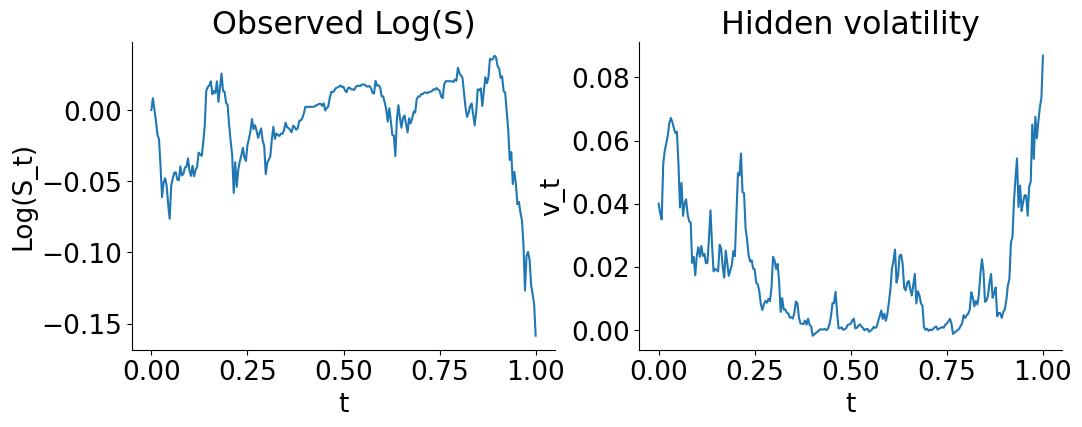

In [5]:
#| echo: false
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(ts, ell_obs)
axs[0].set_title("Observed Log(S)")
axs[0].set_xlabel("t")
axs[0].set_ylabel("Log(S_t)")
axs[1].plot(ts, v_true)
axs[1].set_title("Hidden volatility")
axs[1].set_xlabel("t")
axs[1].set_ylabel("v_t")
plt.show()

The assumption here is that we can only observe $S(t)$ (with this model, it is usually the price of an asset evolving over time) for $t \in \left[0, T\right]$, with a drift driven by an unobserved volatility $v(t)$. The goal is to infer the parameters of the model from the observed trajectory $S(t)$, and either estimate the whole hidden trajectory $v(t)$, or just its final value $v(T)$. In practice, the whole trajectory would be interesting to economists who might want to find out what factors drive the volatility of a given asset, and the final value $v(T)$ would be useful to risk managers who want to simulate the future evolution of $S(t)$ for $t>T$, and especially the range of possible scenarios (which is essential to quantify the uncertainty in these predictions). Concretely, the parameters would let them know how to draw the future curves, and $v(T)$ would inform them on the initial conditions $(S(T), v(T))$ of these future curves.

## Microcanonical Langevin Monte Carlo
The SDE model assumes a continuous $t$, but in practice numerical integrators discretize it into a number of timesteps $t_i$, and $v_i = v(t_i)$ has to be estimated for each of them if we want to reconstruct this hidden part of the process. This is what makes the inference problem high-dimensional and more difficult for Monte Carlo samplers of the posterior distribution. Algorithms based on Hamiltonian dynamics such as HMC or NUTS made some progress in that area, but they can still suffer from slow mixing and poor exploration of the posterior distribution when the energy landscape is complex, for instance when when some variables are highly correlated (like $v_i$ and $v_{i+1}$). [Microcanonical Langevin Monte Carlo](https://proceedings.mlr.press/v253/robnik24a.html) (MCLMC) combines ideas from Hamiltonian dynamics, Langevin diffusion, and microcanonical (i.e. constant-energy in [statistical mechanics parlance](https://en.wikipedia.org/wiki/Microcanonical_ensemble)) sampling, which makes it effective with these problems. In practice, Langevin methods add noise, which improves slow mixing, but this often degrades long-range exploration. MCLMC corrects this degradation by preserving energy over short time.

As a result, MCLMC is especially useful when:
- the posterior is high-dimensional,
- gradients are available,
- the geometry is highly anisotropic,
- long-range exploration matters more than exact reversibility per step.

This makes it attractive for latent time-series models, SDE parameter inference, or Bayesian inverse problems with stiff dynamics.

The Langevin part of MCLMC is itself implemented as a discretized SDE constrained to the energy shell. So if the timestep is too large, if the projection is approximate, or if noise is not exactly tangent, then the discretization can introduce a small stationary bias or an energy drift that invalidates the microcanonical assumption, both of which would impact the exactness of the posterior estimate. A [sanity check suggested in the Blackjax documentation](https://blackjax-devs.github.io/sampling-book/algorithms/mclmc.html#how-to-analyze-the-results-of-your-mclmc-run) is to decrease the step size of the Langevin SDE and see if results remain consistent, or to apply an [adjusted version of MCLMC](https://neurips.cc/virtual/2025/loc/san-diego/poster/117452), also implemented in Blackjax.

In [6]:
#| echo: false
#| output: false

def run_mclmc(logdensity_fn, num_steps, initial_position, key,
              transform, desired_energy_variance= 5e-4):
    init_key, tune_key, run_key = jax.random.split(key, 3)

    # create an initial state for the sampler
    initial_state = blackjax.mcmc.mclmc.init(
        position=initial_position, logdensity_fn=logdensity_fn, rng_key=init_key
    )

    # build the kernel
    kernel = lambda inverse_mass_matrix : blackjax.mcmc.mclmc.build_kernel(
        logdensity_fn=logdensity_fn,
        integrator=blackjax.mcmc.integrators.isokinetic_mclachlan,
        inverse_mass_matrix=inverse_mass_matrix,
    )

    # find values for L and step_size
    (
        blackjax_state_after_tuning,
        blackjax_mclmc_sampler_params,
        _
    ) = blackjax.mclmc_find_L_and_step_size(
        mclmc_kernel=kernel,
        num_steps=num_steps,
        state=initial_state,
        rng_key=tune_key,
        diagonal_preconditioning=False,
        desired_energy_var=desired_energy_variance
    )

    # use the quick wrapper to build a new kernel with the tuned parameters
    sampling_alg = blackjax.mclmc(
        logdensity_fn,
        L=blackjax_mclmc_sampler_params.L,
        step_size=blackjax_mclmc_sampler_params.step_size,
    )

    # run the sampler
    _, samples = blackjax.util.run_inference_algorithm(
        rng_key=run_key,
        initial_state=blackjax_state_after_tuning,
        inference_algorithm=sampling_alg,
        num_steps=num_steps,
        transform=transform,
        progress_bar=True,
    )

    return samples, blackjax_state_after_tuning, blackjax_mclmc_sampler_params, run_key

In [7]:
#| echo: false
#| output: false
import jax
import jax.numpy as jnp
import jax.scipy as jsp
from jax.scipy.special import gammaln, logsumexp

# ----------------------------
# Utilities
# ----------------------------
LOG2PI = jnp.log(2.0 * jnp.pi)

def softplus(x):
    return jax.nn.softplus(x)

def normal_logpdf(x, m, s):
    # s > 0
    z = (x - m) / s
    return -0.5 * (LOG2PI + 2.0 * jnp.log(s) + z * z)

def safe_sqrt(x, eps=1e-12):
    return jnp.sqrt(jnp.maximum(x, eps))


# ----------------------------
# Target builder
# ----------------------------
def make_heston_mclmc_target(
    ell_obs: jnp.ndarray,
    *,
    T: float,
    n_steps: int,
    eps_v: float = 1e-8,
    dt_override: float | None = None,
):
    """
    Build a smooth discrete-time Heston target log density for MCLMC.

    Observations:
      ell_obs: shape [n_steps+1], observed log-price path (or log-index)
      r_t = ell_{t+1} - ell_t are the observed increments.

    Latents / parameters sampled by MCLMC (a convenient unconstrained choice):
      position = {
        "u":    [n_steps+1] unconstrained latent path
                  -> v_t = softplus(u_t) + eps_v
        "mu":   scalar
        "log_kappa": scalar -> kappa = exp(log_kappa)
        "log_theta_v": scalar -> theta_v = exp(log_theta_v)
        "log_xi": scalar -> xi = exp(log_xi)
        "rho_eta": scalar -> rho = tanh(rho_eta)
      }

    The per-step likelihood uses the *joint* discretization
      p(v_{t+1}|v_t) * p(r_t | v_t, v_{t+1})
    so that rho is identifiable.
    """
    ell_obs = jnp.asarray(ell_obs)
    assert ell_obs.ndim == 1, "ell_obs must be 1D"
    assert ell_obs.shape[0] == n_steps + 1, "ell_obs must have length n_steps+1"

    r_obs = ell_obs[1:] - ell_obs[:-1]  # shape [n_steps]

    dt = (T / n_steps) if dt_override is None else dt_override
    dt = jnp.asarray(dt)

    def target_logprob(position):
        u = position["u"]  # shape [n_steps+1]
        mu = position["mu"]
        log_kappa = position["log_kappa"]
        log_theta_v = position["log_theta_v"]
        log_xi = position["log_xi"]
        rho_eta = position["rho_eta"]

        # Transforms
        kappa = jnp.exp(log_kappa)
        theta_v = jnp.exp(log_theta_v)
        xi = jnp.exp(log_xi)
        rho = jnp.tanh(rho_eta)

        # Latent variance path (strictly positive, smooth)
        v = softplus(u) + eps_v  # shape [n_steps+1]
        v_t = v[:-1]             # shape [n_steps]
        v_tp1 = v[1:]            # shape [n_steps]

        # ---- Priors (tweak as you like) ----
        lp = 0.0

        # mu: very weak prior (annualized drift; returns barely identify it)
        lp += normal_logpdf(mu, 0.0, 0.2)

        # kappa, theta_v, xi: log-normal-ish weak priors in "year" units
        # (you can tighten these once stable)
        lp += normal_logpdf(log_kappa, jnp.log(2.0), 0.6)
        lp += normal_logpdf(log_theta_v, jnp.log(0.04), 0.7)
        lp += normal_logpdf(log_xi, jnp.log(0.5), 0.6)

        # Jacobians for exp transforms
        lp += log_kappa + log_theta_v + log_xi

        # rho prior: Normal in Fisher z.
        eta = jnp.arctanh(rho)
        lp += normal_logpdf(eta, jnp.arctanh(-0.7), 0.6)
        # Jacobian for rho = tanh(eta): d rho/d eta = 1 - rho^2
        lp += jnp.log1p(-rho * rho)

        # latent path prior: anchor v0 near 0.04 loosely (optional but helps)
        # Here: log v0 ~ N(log 0.04, 1)
        lp += normal_logpdf(jnp.log(v[0]), jnp.log(0.04), 1.0)

        # Jacobian for v = softplus(u)+eps: dv/du = sigmoid(u)
        # (eps_v constant drops out)
        lp += jnp.sum(jnp.log(jax.nn.sigmoid(u)))

        # ---- Transitions / likelihood ----
        # v transition: v_{t+1} | v_t ~ N(mv, sv^2)
        mv = v_t + kappa * (theta_v - v_t) * dt
        sv = xi * safe_sqrt(v_t) * jnp.sqrt(dt)  # > 0
        lp += jnp.sum(normal_logpdf(v_tp1, mv, sv))

        # returns conditional given (v_t, v_{t+1}) so rho enters the mean + variance
        # m_ell = (mu - 0.5 v_t) dt + (rho/xi) [ v_{t+1} - v_t - kappa(theta_v-v_t) dt ]
        innov_v = v_tp1 - v_t - kappa * (theta_v - v_t) * dt
        m_ell = (mu - 0.5 * v_t) * dt + (rho / xi) * innov_v
        s_ell = safe_sqrt(v_t) * jnp.sqrt((1.0 - rho * rho) * dt)  # > 0
        lp += jnp.sum(normal_logpdf(r_obs, m_ell, s_ell))

        return lp

    return target_logprob

In [8]:
#| echo: false
#| output: false
target_logprob_fn = make_heston_mclmc_target(ell_obs, T=T_total, n_steps=n_steps)
position0 = {
  "u": jnp.log(jnp.expm1(jnp.ones((n_steps+1,)) * 0.04)),  # rough inverse-softplus init (optional)
  "mu": 0.0,
  "log_kappa": jnp.log(1.0),
  "log_theta_v": jnp.log(0.04),
  "log_xi": jnp.log(0.5),
  "rho_eta": jnp.arctanh(-0.5),
}
lp0 = target_logprob_fn(position0)

In [9]:
#| echo: false
#| output: false
num_steps = 20000

# Define transform to save the position from the sampler state
# Updated to accept 'info' argument required by blackjax
def transform(state, info):
    return state.position

sample_key, rng_key = jax.random.split(rng_key)
samples_ou, initial_state_ou, params_ou, chain_key_ou = run_mclmc(
    logdensity_fn=target_logprob_fn,
    num_steps=num_steps,
    initial_position=position0,
    key=sample_key,
    transform=transform
)

print("MCLMC sampling for OU SDE completed. Samples stored in `samples_ou`.")

<div><progress max="20000" value="20000"></progress> 100.00% [20000/20000 00:00&lt;?]</div>

MCLMC sampling for OU SDE completed. Samples stored in `samples_ou`.


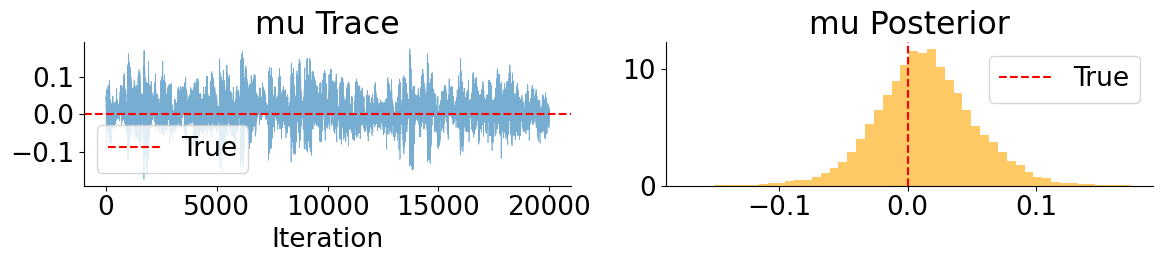

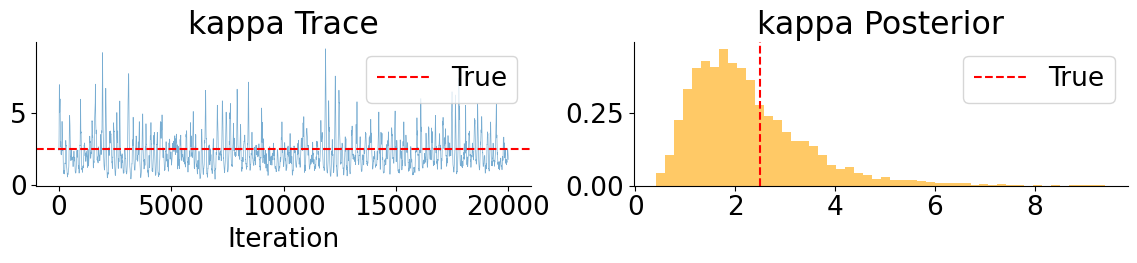

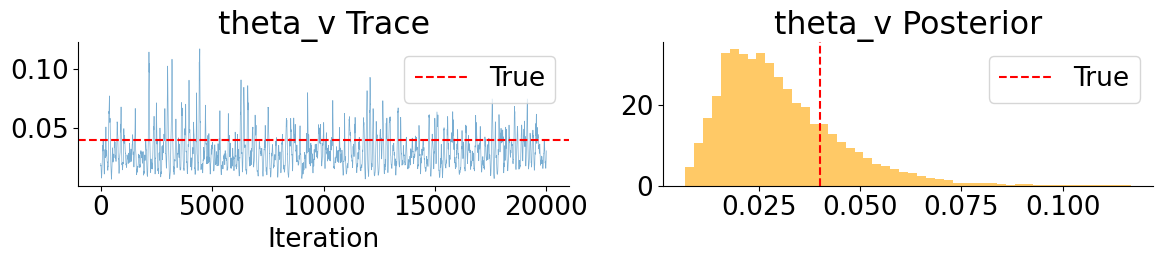

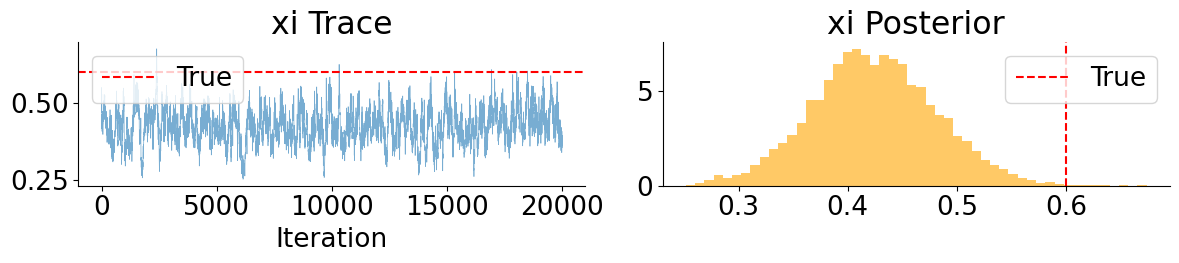

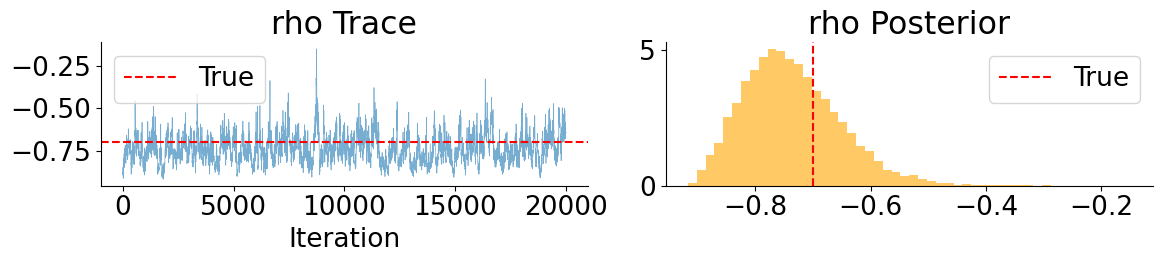

In [10]:
#| echo: false
# Transform samples back to natural scale
kappa_samples = jnp.exp(samples_ou['log_kappa'])
theta_v_samples = jnp.exp(samples_ou['log_theta_v'])
xi_samples = jnp.exp(samples_ou['log_xi'])
rho_samples = jnp.tanh(samples_ou['rho_eta'])
mu_samples = samples_ou['mu']

# Helper to plot trace and hist
def plot_param_posterior(name, samples, true_val=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))

    # Trace
    axes[0].plot(samples, alpha=0.6, lw=0.5)
    axes[0].set_title(f'{name} Trace')
    axes[0].set_xlabel('Iteration')
    if true_val is not None:
        axes[0].axhline(true_val, color='r', linestyle='--', label='True')
        axes[0].legend()

    # Hist
    axes[1].hist(samples, bins=50, density=True, alpha=0.6, color='orange')
    axes[1].set_title(f'{name} Posterior')
    if true_val is not None:
        axes[1].axvline(true_val, color='r', linestyle='--', label='True')
        axes[1].legend()

    plt.tight_layout()
    plt.show()

# True values from simulation: mu=0.0, kappa=2.5, theta_v=0.04, xi=0.6, rho=-0.7
plot_param_posterior('mu', mu_samples, 0.0)
plot_param_posterior('kappa', kappa_samples, 2.5)
plot_param_posterior('theta_v', theta_v_samples, 0.04)
plot_param_posterior('xi', xi_samples, 0.6)
plot_param_posterior('rho', rho_samples, -0.7)

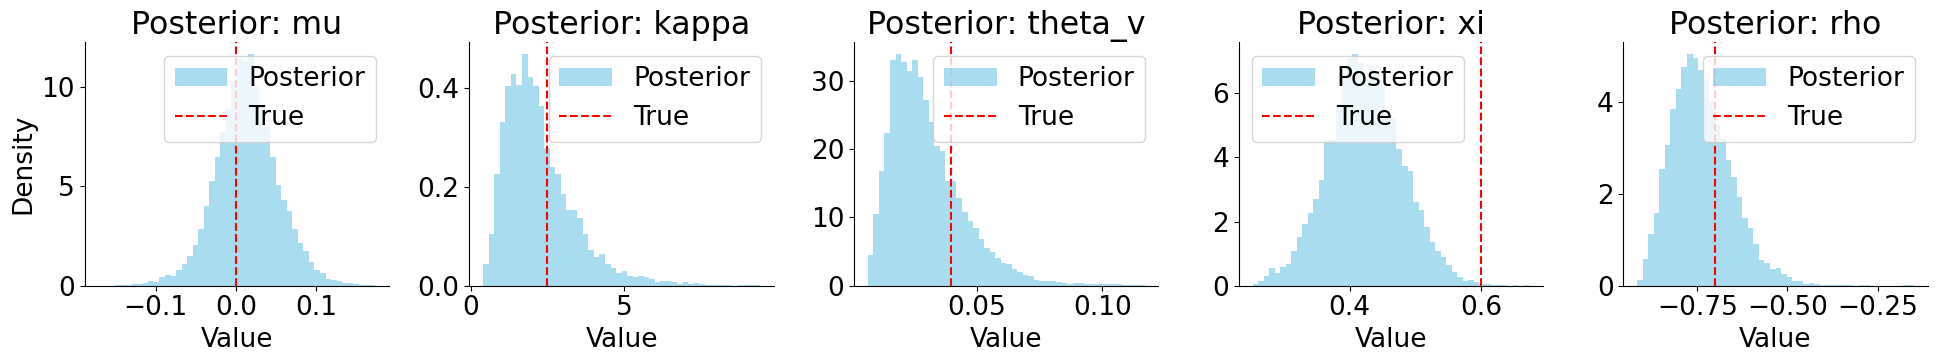

In [11]:
#| echo: false
#| output: false
param_names = ['mu', 'kappa', 'theta_v', 'xi', 'rho']
true_vals = true_params

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
axes[0].hist(mu_samples, bins=50, density=True, color='skyblue', alpha=0.7, label='Posterior')
axes[1].hist(kappa_samples, bins=50, density=True, color='skyblue', alpha=0.7, label='Posterior')
axes[2].hist(theta_v_samples, bins=50, density=True, color='skyblue', alpha=0.7, label='Posterior')
axes[3].hist(xi_samples, bins=50, density=True, color='skyblue', alpha=0.7, label='Posterior')
axes[4].hist(rho_samples, bins=50, density=True, color='skyblue', alpha=0.7, label='Posterior')

for i, ax in enumerate(axes):
    ax.axvline(true_vals[i], color='r', linestyle='--', label='True')
    ax.set_title(f'Posterior: {param_names[i]}')
    ax.set_xlabel('Value')
    if i == 0:
        ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()

These MCLMC marginals reveal a clear separation between well- and weakly-behaved parameters. Drift and leverage parameters ($\mu$ and $\rho$) are accurately recovered and exhibit good mixing, while mean-reversion parameters ($\kappa$ and $\theta_v$) remain weakly identified but consistent with the true values. In contrast, the volatility-of-volatility parameter $\xi$ is systematically underestimated, with the true value lying in the tail of the posterior. This bias is not due to poor mixing, but is consistent with Euler discretization effects in SDE parameter inference, where diffusion parameters absorb model error when the discretized dynamics are treated as exact.

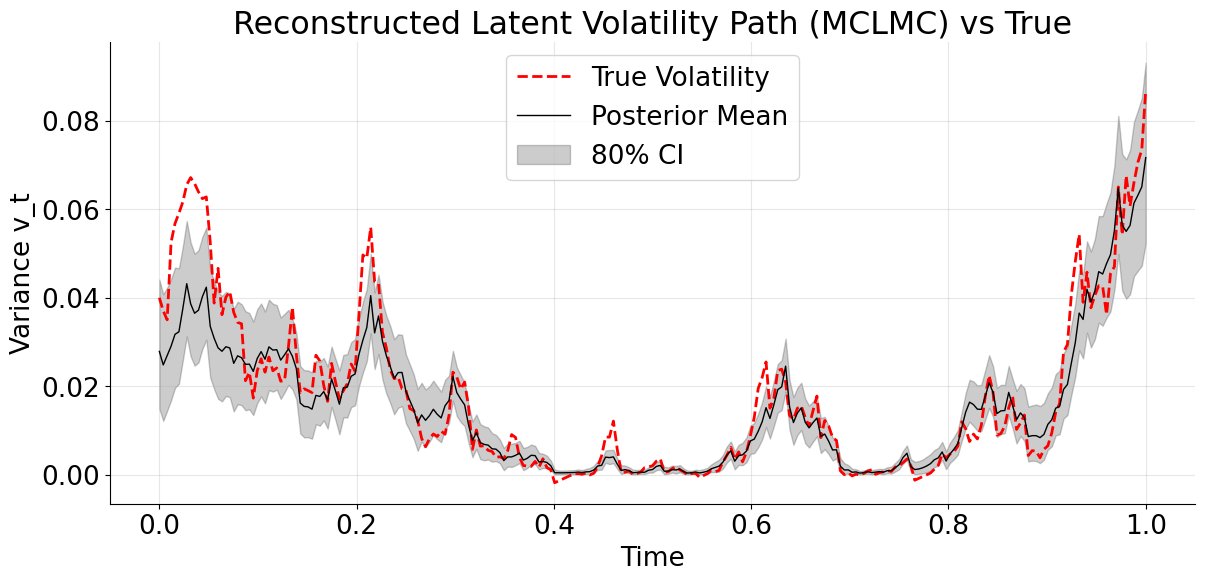

In [12]:
#| echo: false

# Reconstruct Volatility Path
# v = softplus(u) + 1e-8 (matches target definition)
v_samples = jax.nn.softplus(samples_ou['u']) + 1e-8

# Calculate statistics
v_mean = jnp.mean(v_samples, axis=0)
v_lower = jnp.percentile(v_samples, 10, axis=0)
v_upper = jnp.percentile(v_samples, 90, axis=0)

plt.figure(figsize=(14, 6))
plt.plot(ts, v_true, 'r--', label='True Volatility', lw=2)
plt.plot(ts, v_mean, 'k-', label='Posterior Mean', lw=1)
plt.fill_between(ts, v_lower, v_upper, color='k', alpha=0.2, label='80% CI')
plt.title('Reconstructed Latent Volatility Path (MCLMC) vs True')
plt.xlabel('Time')
plt.ylabel('Variance v_t')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The MCLMC-smoothed volatility path correctly captures the temporal structure of volatility regimes, but exhibits systematic amplitude damping, with peaks consistently lower than the true latent path. This behavior mirrors the downward bias observed in the inferred volatility-of-volatility parameter and reflects the tendency of Euler-discretized gradient-based inference to favor smoother latent trajectories when discretization error is treated as exact. Also note that the 80% credible interval tightens in low-vol regimes and widens during spikes, with no pathological overconfidence.



## Hybrid inference

The MCLMC results highlight a key limitation of gradient-based inference for discretized stochastic volatility models: while the temporal structure of the latent volatility is recovered, diffusion parameters are biased and volatility amplitudes are systematically damped. This motivates a different strategy that avoids differentiating through discretized latent paths altogether. In this section, we adopt a hybrid approach that combines neural posterior estimation (NPE) for fast, amortized parameter inference with particle filtering for latent state inference. This decouples parameter learning from latent path discretization, while retaining principled uncertainty quantification.

### Neural posterior estimation of the SDE parameters

The general idea of neural network methods in simulation-based inference is to sample model parameters from a prior distribution,

$$
\theta \sim \pi(\theta),
$$

and use a pure simulator model to generate synthetic observations

$$
x = f_{sim}(\theta).
$$

The difference with a standard statistical model is that the simulator model does not need to come with a likelihood function. Instead, we assume that the pairs $(\theta, x)$ are drawn from an unknown joint distribution,

$$
(\theta, x) \sim P(\theta, x) = \pi(\theta)\, P(x \vert \theta),
$$

and we use conditional neural density estimation on this synthetic data to estimate quantities of interest, like the intractable likelihood when conditioning on $\theta$, or a posterior density estimator when conditioning on $x$. See this [practical guide](https://arxiv.org/abs/2508.12939) for more details.

In the case of SDE, it means that we only need to use the integrator to simulate realizations of the process.

The main benefits of NPE in SDE problems are that it avoids taking gradients through noisy simulators, and amortized inference is cheap at test time.

Nevertheless, NPE is not a silver bullet as neural density estimation is most effective in relatively low dimensions. We can use it to infer the parameters $\theta$, but the hidden volatility trajectory $v_t$ would probably be too much, which is why we defer its esimation to a second stage based on [particle filtering](https://en.wikipedia.org/wiki/Particle_filter). Likewise, on the input side, the dimensionality of the full trajectory of $S_t$ is too high, but we can condense it into carefully crafted summary statistics.

In [13]:
#| echo: false
#| output: false

def sample_theta_for_npe(key, n):
    k1, k2, k3, k4, k5 = jax.random.split(key, 5)

    mu = 0.2 * jax.random.normal(k1, (n,))          # or zeros

    log_kappa = jnp.log(2.0)  + 0.6 * jax.random.normal(k2, (n,))
    log_theta = jnp.log(0.04) + 0.7 * jax.random.normal(k3, (n,))
    log_xi    = jnp.log(0.5)  + 0.6 * jax.random.normal(k4, (n,))

    kappa = jnp.exp(log_kappa)
    theta = jnp.exp(log_theta)
    xi    = jnp.exp(log_xi)

    # rho via Fisher z centered negative
    eta = jnp.arctanh(-0.7) + 0.6 * jax.random.normal(k5, (n,))
    rho = jnp.tanh(eta)

    return jnp.stack([mu, kappa, theta, xi, rho], axis=-1)

def theta_to_z(theta):
    mu, kappa, theta_v, xi, rho = theta
    return jnp.array([
        mu,
        jnp.log(kappa),
        jnp.log(theta_v),
        jnp.log(xi),
        jnp.arctanh(jnp.clip(rho, -0.999, 0.999)),
    ])

def z_to_theta(z):
    mu, log_kappa, log_theta, log_xi, eta = z
    return jnp.array([
        mu,
        jnp.exp(log_kappa),
        jnp.exp(log_theta),
        jnp.exp(log_xi),
        jnp.tanh(eta),
    ])

def logprior_z(z):
    mu, log_kappa, log_theta, log_xi, eta = z

    lp = 0.0
    lp += js.norm.logpdf(mu, 0.0, 0.2)
    lp += js.norm.logpdf(log_kappa, jnp.log(2.0), 0.6)
    lp += js.norm.logpdf(log_theta, jnp.log(0.04), 0.7)
    lp += js.norm.logpdf(log_xi, jnp.log(0.5), 0.6)
    lp += js.norm.logpdf(eta, jnp.arctanh(-0.7), 0.6)
    return lp


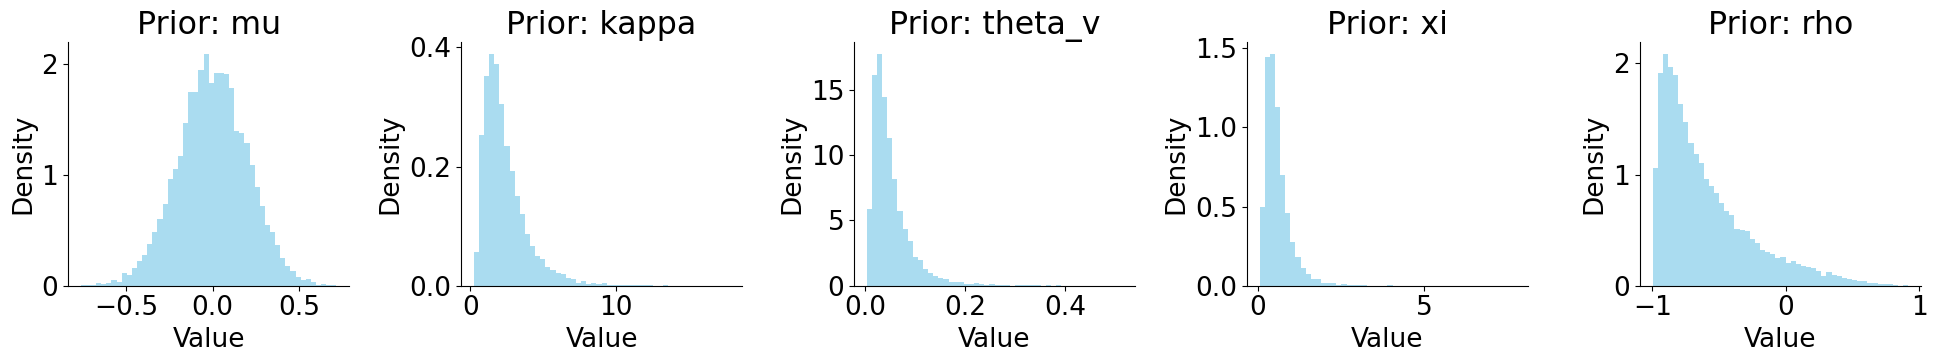

In [14]:
#| echo: false
#| output: false

# Prior predictive checks
key_prior = jax.random.PRNGKey(42)
n_prior_samples = 10_000
theta_prior_samples = sample_theta_for_npe(key_prior, n_prior_samples)

# Plot histograms
param_names = ['mu', 'kappa', 'theta_v', 'xi', 'rho']
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, ax in enumerate(axes):
    ax.hist(theta_prior_samples[:, i], bins=50, density=True, color='skyblue', alpha=0.7)
    ax.set_title(f'Prior: {param_names[i]}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')

plt.tight_layout()
plt.show()

In [15]:
#| echo: false
#| output: false

def _autocorr(x, lag):
    x = x - jnp.mean(x)
    n = x.shape[0]
    lag = int(lag)
    return jnp.where(
        n > lag + 1,
        jnp.sum(x[lag:] * x[:-lag]) / (jnp.sum(x[:-lag]**2) + 1e-8),
        0.0,
    )

def _corr(a, b):
    a = a - jnp.mean(a)
    b = b - jnp.mean(b)
    den = jnp.sqrt(jnp.sum(a*a) * jnp.sum(b*b)) + 1e-8
    return jnp.sum(a * b) / den

def leverage_frv(r, dt, m=10):
    r2a = (r*r) / dt
    w = jnp.ones((m,), dtype=r.dtype) / m
    frv = jnp.convolve(r2a[1:], w, mode="valid")   # future RV
    rt = r[:frv.shape[0]]
    return _corr(rt, frv)

def rv_term_structure(r, dt, n_blocks=8):
    T = r.shape[0]
    m = (T // n_blocks) * n_blocks
    r = r[:m]
    blocks = r.reshape(n_blocks, -1)
    rvb = jnp.mean(blocks**2, axis=1) / dt  # annualized block RV

    slope = _corr(jnp.arange(n_blocks).astype(r.dtype), rvb)
    ac1 = _autocorr(rvb, 1)
    ac2 = _autocorr(rvb, 2)
    return jnp.array([jnp.mean(rvb), jnp.var(rvb), slope, ac1, ac2])

def summarize_returns(r, dt):
    r2a = (r*r) / dt

    m  = jnp.mean(r)                          # optional
    rv = jnp.mean(r2a)
    rq = jnp.mean(r2a*r2a)

    ac1 = _autocorr(r2a, 1)
    ac5 = _autocorr(r2a, 5)

    lev5  = leverage_frv(r, dt, 5)
    lev20 = leverage_frv(r, dt, 20)

    ts = rv_term_structure(r, dt, n_blocks=8)

    return jnp.concatenate([jnp.array([m, rv, rq, ac1, ac5, lev5, lev20]), ts])


These include realized variance and higher moments to capture volatility scale, autocorrelations of squared returns to capture persistence, explicit leverage statistics linking returns to future volatility, and a coarse term structure of realized variance to encode longer-horizon dynamics. This choice balances expressiveness and robustness: the summaries are informative about the Heston parameters while avoiding the curse of dimensionality and excessive sensitivity to discretization noise.

In [16]:
#| echo: false
#| output: false

@partial(jax.jit, static_argnames=("n_steps",))
def simulate_one_x(key, theta, *, T=1.0, n_steps=252, ell0=0.0):
    mu, kappa, theta_v, xi, rho = theta
    v0 = theta_v
    ts, ell, v = simulate_heston(key, theta, T=T, n_steps=n_steps, ell0=ell0, v0=v0)
    r = jnp.diff(ell)
    x = summarize_returns(r, dt=T/n_steps)
    z = theta_to_z(theta)
    return x, r, v, z  # IMPORTANT: train NPE in z-space (unconstrained)

def make_dataset(key, n, *, T=1.0, n_steps=252):
    key_z, key_sim = jax.random.split(key, 2)
    thetas = sample_theta_for_npe(key_z, n)
    keys = jax.random.split(key_sim, n)

    xs, _, _, zs_out = jax.vmap(lambda k, theta: simulate_one_x(k, theta, T=T, n_steps=n_steps))(keys, thetas)
    return xs, zs_out


The heaviest coding in this pipeline is the implementation of the neural density estimation model. As mentioned in the introduction, the Distrax library contains all the required building blocks, but putting them together can be tedious, especially if the parameters require unconstraining bijectors to map them to $\mathbb{R}$. The relevant [flow model example](https://github.com/google-deepmind/distrax/blob/main/examples/flow.py) in the library documentation is a good starting point.

In [17]:
#| echo: false
#| output: false

def init_mlp(key, in_dim, hidden_dims, out_dim):
    dims = [in_dim] + list(hidden_dims) + [out_dim]
    keys = jax.random.split(key, len(dims) - 1)
    params = []
    for k, (d0, d1) in zip(keys, zip(dims[:-1], dims[1:])):
        W = jax.random.normal(k, (d0, d1)) / jnp.sqrt(d0)
        b = jnp.zeros((d1,))
        params.append((W, b))
    return params

def mlp_apply(params, x):
    for i, (W, b) in enumerate(params):
        x = x @ W + b
        if i < len(params) - 1:
            x = jax.nn.silu(x)
    return x

def make_conditional_coupling_flow(key, z_dim, cond_dim, n_layers=4, hidden=64):
    """
    Returns:
      flow: a distrax bijector Chain
      cond_params: list of MLP params, one per coupling layer
      masks: list of boolean masks, one per layer
    """
    keys = jax.random.split(key, n_layers)
    masks = [(jnp.arange(z_dim) % 2 == (i % 2)) for i in range(n_layers)]

    cond_params = []
    bijectors = []

    for i in range(n_layers):
        mask = masks[i]
        # Conditioner input is the *masked* part + cond
        in_dim = z_dim + cond_dim
        out_dim = 2 * z_dim  # shift + log_scale (we'll zero-out masked dims)
        params_i = init_mlp(keys[i], in_dim, [hidden, hidden], out_dim)
        cond_params.append(params_i)

        # distrax.MaskedCoupling calls conditioner_fn(x_masked) -> (shift, log_scale)
        # We build x_masked ourselves and concatenate cond inside the closure.
        def make_conditioner(params_i, mask):
            def conditioner_fn(x, cond):
                # x is full z; MaskedCoupling will pass x with masked dims zeroed,
                # but we can safely just use x as given.
                h = jnp.concatenate([x, cond], axis=-1)
                out = mlp_apply(params_i, h)
                shift, log_scale = jnp.split(out, 2, axis=-1)
                # Only apply to the *unmasked* part (coupling convention)
                shift = shift * (~mask)
                log_scale = log_scale * (~mask)
                # clamp for stability
                log_scale = jnp.clip(log_scale, -5.0, 5.0)
                return shift, log_scale
            return conditioner_fn

        # We can't pass (x, cond) directly to MaskedCoupling's conditioner (it only passes x),
        # so we implement coupling ourselves with a custom bijector wrapper below.
        bijectors.append(("coupling", mask, params_i))

        bijectors.append(("permute", None, None))

    return cond_params, masks, bijectors

In [18]:
#| echo: false
#| output: false

def coupling_forward(z, cond, mask, mlp_params):
    # mask: True means "masked / frozen" part; transform the ~mask part
    h = jnp.concatenate([z * mask, cond], axis=-1)
    out = mlp_apply(mlp_params, h)
    shift, log_scale = jnp.split(out, 2, axis=-1)
    shift = shift * (~mask)
    log_scale = jnp.clip(log_scale * (~mask), -5.0, 5.0)

    z_out = z * mask + (z * (~mask)) * jnp.exp(log_scale) + shift
    logdet = jnp.sum(log_scale, axis=-1)
    return z_out, logdet

def coupling_inverse(z, cond, mask, mlp_params):
    h = jnp.concatenate([z * mask, cond], axis=-1)
    out = mlp_apply(mlp_params, h)
    shift, log_scale = jnp.split(out, 2, axis=-1)
    shift = shift * (~mask)
    log_scale = jnp.clip(log_scale * (~mask), -5.0, 5.0)

    z_in = z * mask + ((z - shift) * (~mask)) * jnp.exp(-log_scale)
    logdet = -jnp.sum(log_scale, axis=-1)
    return z_in, logdet


In [19]:
#| echo: false
#| output: false

z_dim = 5
cond_dim = 12
n_layers=4


masks = [(jnp.arange(z_dim) % 2 == (i % 2)) for i in range(n_layers)]

z0 = jax.random.normal(jax.random.PRNGKey(0), (8, z_dim))
cond0 = jax.random.normal(jax.random.PRNGKey(1), (8, cond_dim))
mask0 = masks[0]

# Initialize properly shaped params for the test
# Input: z (masked) + cond. Output: shift + scale for z
key_params = jax.random.PRNGKey(42)
params0 = init_mlp(key_params, z_dim + cond_dim, [32], 2 * z_dim)

z1, ld_f = coupling_forward(z0, cond0, mask0, params0)
z0_rec, ld_inv = coupling_inverse(z1, cond0, mask0, params0)

print("max recon err:", jnp.max(jnp.abs(z0_rec - z0)))
print("max ld_f + ld_inv:", jnp.max(jnp.abs(ld_f + ld_inv)))

max recon err: 2.3841858e-07
max ld_f + ld_inv: 0.0


In [20]:
#| echo: false
#| output: false

def std_normal_logprob(z):
    d = z.shape[-1]
    return -0.5 * (jnp.sum(z*z, axis=-1) + d * jnp.log(2 * jnp.pi))

def flow_log_prob(z, cond, masks, bijector_specs):
    # bijector_specs is list of ("coupling"/"permute", mask, params)
    logdet_total = 0.0
    u = z
    for kind, mask, params in bijector_specs:
        if kind == "coupling":
            u, ld = coupling_forward(u, cond, mask, params)
            logdet_total = logdet_total + ld
        else:  # permute
            u = u[..., ::-1]
    return std_normal_logprob(u) + logdet_total


The model is trained by minimizing the negative log-likelihood of the synthetic data.

In [21]:
#| echo: false
#| output: false
import jax
import jax.numpy as jnp
import optax

def train_npe(
    key,
    xs,
    zs,
    *,
    n_steps=20_000,
    batch_size=512,
    lr=3e-4,
    cond_dim=16,
    n_layers=4,
    hidden=64,
):
    n, x_dim = xs.shape
    z_dim = zs.shape[1]

    key_enc, key_flow, key_loop = jax.random.split(key, 3)

    enc_params = init_mlp(key_enc, x_dim, [64, 64], cond_dim)
    cond_params, masks, _ = make_conditional_coupling_flow(
        key_flow, z_dim=z_dim, cond_dim=cond_dim, n_layers=n_layers, hidden=hidden
    )

    params = (enc_params, cond_params)

    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)

    # ---- JIT step closes over optimizer & masks (no Python objects passed in) ----
    @jax.jit
    def train_step(params, opt_state, bx, bz):
        enc_params, cond_params = params

        def loss_fn(params):
            enc_params, cond_params = params
            cond = jax.vmap(lambda x: mlp_apply(enc_params, x))(bx)  # [B, cond_dim]

            # build forward specs using *current* cond_params
            specs = []
            L = len(cond_params)
            for i in range(L):
                specs.append(("coupling", masks[i], cond_params[i]))
                specs.append(("permute", None, None))

            lp = jax.vmap(lambda z, c: flow_log_prob(z, c, masks, specs))(bz, cond)
            return -jnp.mean(lp)

        loss, grads = jax.value_and_grad(loss_fn)(params)
        updates, opt_state = optimizer.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)
        return params, opt_state, loss
    # ---------------------------------------------------------------------------

    for step in range(n_steps):
        key_loop, sub = jax.random.split(key_loop)
        idx = jax.random.randint(sub, (batch_size,), 0, n)
        bx, bz = xs[idx], zs[idx]
        params, opt_state, loss = train_step(params, opt_state, bx, bz)

        if step % 500 == 0:
            print(f"step {step}: loss={float(loss):.4f}")

    return {"params": params, "masks": masks, "z_dim": z_dim, "cond_dim": cond_dim}


In [22]:
#| echo: false
#| output: false
def flow_sample(key, cond, enc_params, cond_params, masks, n_samples):
    u = jax.random.normal(key, (n_samples, cond.shape[-1] * 0 + len(masks)*0 + cond_params[0][-1][1].shape[0]*0 + 0,))  # dummy


Once this is done, we get a flow-based distribution $q_{nn}(\theta \vert x)$ that is an approximation of the true posterior $p(\theta \vert x)$. The vector of summary statistics $x_{obs}$ of the observed trajectory $S_{1:T}$ is passed to the conditional flow model as the conditioning variable, and we can draw Monte Carlo samples

$$
\theta^{(i)} \sim q_{nn}(\theta \vert x_{obs}) \approx p(\theta \vert x_{obs}), \quad i=1,\dots ,\, M
$$

The downstream task of particle filtering requires the values of the parameters transformed by the unconstraining bijectors, and the posterior log-densities of these sampled parameter values if we find we need to improve the approximation $q_{nn}(\theta \vert x_{obs}) \approx p(\theta \vert x_{obs})$ with corrective weights, so the best is to wrap the neural sampler into a function that returns the parameters, their unconstrained versions, along with their posterior log-densities.


In [23]:
#| echo: false
#| output: false
def sample_posterior(key, trained_state, x_obs, n_samples=10_000):
    enc_params, cond_params = trained_state["params"]
    masks = trained_state["masks"]
    z_dim = trained_state["z_dim"]

    # cond: (cond_dim,)
    cond = mlp_apply(enc_params, x_obs)

    # Broadcast cond to (n_samples, cond_dim)
    cond_b = jnp.broadcast_to(cond, (n_samples, cond.shape[-1]))

    u = jax.random.normal(key, (n_samples, z_dim))

    # Inverse through coupling layers
    z = u
    logdet_inv_total = 0.0
    L = len(cond_params)
    for i in reversed(range(L)):
        z = z[..., ::-1]  # undo permutation
        z, ld = coupling_inverse(z, cond_b, masks[i], cond_params[i])  # <-- pass batched cond
        logdet_inv_total += ld

    log_prob_z = std_normal_logprob(u) - logdet_inv_total

    # Compute theta and apply Jacobian correction for log_prob_theta
    def transform_with_logdet(z_i):
        mu, log_kappa, log_theta, log_xi, eta = z_i

        # Transform
        kappa = jnp.exp(log_kappa)
        theta_v = jnp.exp(log_theta)
        xi = jnp.exp(log_xi)
        rho = jnp.tanh(eta)
        theta_val = jnp.array([mu, kappa, theta_v, xi, rho])

        # Jacobian log-det
        # Diagonal terms: 1, kappa, theta_v, xi, 1-rho^2
        ld = log_kappa + log_theta + log_xi + jnp.log1p(-rho**2)
        return theta_val, ld

    theta, log_det_J = jax.vmap(transform_with_logdet)(z)
    log_prob_theta = log_prob_z - log_det_J

    return z, theta, log_prob_z, log_prob_theta

In [24]:
#| echo: false
#| output: false
r_obs = jnp.diff(ell_obs)
x_obs = summarize_returns(r_obs, dt=T_total/n_steps)
theta_true = true_params

In [25]:
#| echo: false
#| output: false

# 1) Create ground-truth observation
key = jax.random.PRNGKey(0)
#z_true = jnp.array([0.0, 1.0, -2.0, 0.0, -1.0])  # unconstrained
#theta_true = z_to_params(z_true)

key_data, key_train, key_post = jax.random.split(key, 3)
#x_obs, r_obs, v_true, _ = simulate_one_x(key_obs, z_true, T=4.0, n_steps=252)

# 2) Simulate SBI dataset
xs, zs = make_dataset(key_data, n=50_000, T=4.0, n_steps=252)

x_mean = jnp.mean(xs, axis=0)
x_std  = jnp.std(xs, axis=0) + 1e-6

xs_n = (xs - x_mean) / x_std
x_obs_n = (x_obs - x_mean) / x_std

# 3) Train NPE
trained_state = train_npe(key_train, xs_n, zs, batch_size=512, lr=1e-4)

# 4) Sample posterior
z_samps, theta_samps, log_prob_z_samps, log_prob_theta_samps = sample_posterior(key_post, trained_state, x_obs_n, n_samples=20_000)

# Posterior means (rough quick check)
print("true theta:", theta_true)
print("post mean :", jnp.mean(theta_samps, axis=0))
print("post std  :", jnp.std(theta_samps, axis=0))

step 0: loss=11.3228
step 500: loss=6.7191
step 1000: loss=5.4148
step 1500: loss=4.0112
step 2000: loss=3.2702
step 2500: loss=2.6546
step 3000: loss=2.1921
step 3500: loss=1.7489
step 4000: loss=1.6552
step 4500: loss=1.6773
step 5000: loss=1.5996
step 5500: loss=1.3222
step 6000: loss=1.4358
step 6500: loss=1.2628
step 7000: loss=1.3628
step 7500: loss=1.4581
step 8000: loss=1.2826
step 8500: loss=1.3630
step 9000: loss=1.3111
step 9500: loss=1.1528
step 10000: loss=1.2123
step 10500: loss=1.0801
step 11000: loss=0.9752
step 11500: loss=1.0381
step 12000: loss=1.0526
step 12500: loss=1.0094
step 13000: loss=0.9385
step 13500: loss=0.9335
step 14000: loss=0.9604
step 14500: loss=0.8542
step 15000: loss=1.0037
step 15500: loss=0.8827
step 16000: loss=1.0156
step 16500: loss=0.8137
step 17000: loss=0.7981
step 17500: loss=0.9080
step 18000: loss=0.7394
step 18500: loss=0.8059
step 19000: loss=0.6548
step 19500: loss=0.7826
true theta: (0.0, 2.5, 0.04, 0.6, -0.7)
post mean : [-0.0420298

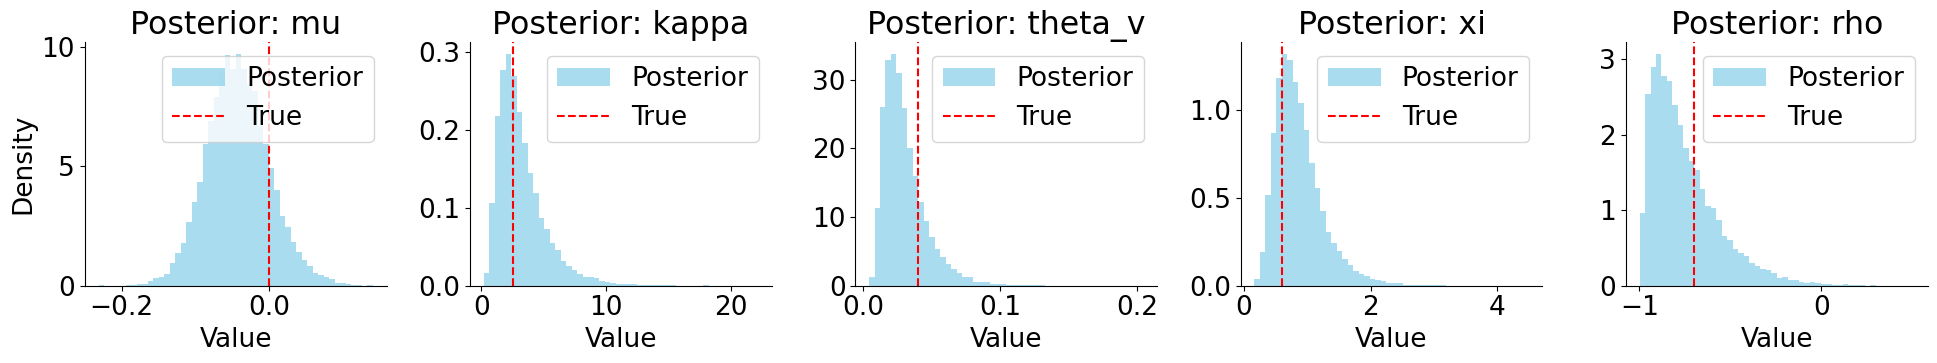

In [26]:
#| echo: false
param_names = ['mu', 'kappa', 'theta_v', 'xi', 'rho']
true_vals = true_params

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, ax in enumerate(axes):
    ax.hist(theta_samps[:, i], bins=50, density=True, color='skyblue', alpha=0.7, label='Posterior')
    ax.axvline(true_vals[i], color='r', linestyle='--', label='True')
    ax.set_title(f'Posterior: {param_names[i]}')
    ax.set_xlabel('Value')
    if i == 0:
        ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()

The neural posterior exhibits the expected skewness and uncertainty structure of the Heston model, with weak identifiability for diffusion parameters and good recovery of drift and leverage effects, indicating a well-calibrated amortized approximation.

Compared to MCLMC, NPE produces less concentrated but better-calibrated posteriors, avoiding discretization-induced bias at the cost of explicitly acknowledging weak identifiability.

### Particle filtering

In certain applications, estimating the SDE parameters is enough, but if we want to forecast the future evolution of the process, we need to know the distribution of $v_T$ as well. For a given estimate $\hat\theta$ of the SDE parameters $\theta$, which can be for instance the Monte Carlo estimate $\sum_{i=1}^M \theta^{(i)}$ of the posterior mean or just a single $\theta^{(i)}$, we can run a particle filter to infer the hidden states.

In the Bayesian philosophy, we would prefer to marginalize out the SDE parameters,

$$
p(v_T \vert S_{1:T})
\;=\;
\int p(v_T \vert S_{1:T}, \theta)\, p(\theta \vert S_{1:T}) \, d\theta.
$$

The best approximation we have of this integral is a Monte Carlo estimate,

$$
p(v_T \vert S_{1:T})
\;\approx\;
\frac{1}{M}
\sum_{m=1}^M
p\!\left(v_T \vert S_{1:T}, \theta^{(m)}\right),
\qquad
\theta^{(i)} \sim q_{nn}(\theta \vert x_{obs}) \approx p(\theta \vert x_{obs})
$$

where the terms can be in turn approximated by the particle filter we discussed,

$$
p\!\left(v_T \vert S_{1:T}, \theta^{(m)}\right)
\;\approx\;
\sum_{i=1}^N
w_T^{(m,i)}\,
\delta\!\left(v_T - v_T^{(m,i)}\right),
$$

and overall we get the double sum of weighted particles

$$
p(v_T \vert S_{1:T})
\;\approx\;
\frac{1}{M}
\sum_{m=1}^M
\sum_{i=1}^N
w_T^{(m,i)}\,
\delta\!\left(v_T - v_T^{(m,i)}\right).
$$

The relative weights of the particles of two parameter vectors $\theta^{(k)}$ $\theta^{(l)}$ are the same, but since they are drawn from an approximation $q_{nn}(\theta \vert x_{obs}) \approx p(\theta \vert x_{obs})$ of the true posterior, we might find while running the particle filter that $\theta^{(k)}$ explains the whole sequence of observatons $S_{1:T}$ better than $\theta^{(l)}$ and thus deserves a higher weight.

Concretely, for every $\theta^{(m)}$, the particle filter estimates the actual marginal likelihood of the observation $p_{pf}(x_{obs}|\theta^{(m)})$. We can then calculate importance weights that correct the mismatch with the neural estimation of the posterior,

$$
w_m \propto \frac{p_{pf}(x_{obs}|\theta^{(m)})\, \pi(\theta^{(m)})}{q_{nn}(\theta^{(m)}|x)}.
$$

The calculation of these importance weights is the reason why we recorded the log-densities when sampling from the flow model.

In practice,$p_{pf}(x_{obs}|\theta^{(m)})$ is also an inexact approximation, so a tempering exponent $\alpha$ should be applied to these importance weights.

$$
\tilde w_m(\alpha) \propto
\left(
\frac{p_{pf}(x_{obs}|\theta^{(m)})\, \pi(\theta^{(m)})}{q_{nn}(\theta^{(m)}|x)}
\right)^\alpha,
\qquad \alpha \in [0,1].
$$

The tempering parameter $\alpha$ interpolates between the neural posterior (
$\alpha = 0$) and a fully particle filter likelihood-corrected posterior ($\alpha = 1$), mitigating importance weight degeneracy caused by noisy particle filter likelihood estimates.

To tune the value of $\alpha$, comparing the effective sample size with the number of particles is a good rule of thumbs.

The result is a large pool of weighted particles approximating the full marginal posterior of the final volatility $p(v_{T} | S_{1:T})$, accounting for parameter uncertainty.

In [27]:
#| echo: false
#| output: false
import jax
import jax.numpy as jnp
from jax.scipy.special import logsumexp

def _normal_logpdf(x, mean, std):
    z = (x - mean) / std
    return -0.5 * (jnp.log(2.0 * jnp.pi) + 2.0 * jnp.log(std) + z * z)

def _systematic_resample(key, w):
    """
    Systematic resampling from normalized weights w (sum w = 1).
    """
    N = w.shape[0]
    cdf = jnp.cumsum(w)
    u0 = jax.random.uniform(key, ()) / N
    u = u0 + (jnp.arange(N, dtype=w.dtype) / N)
    idx = jnp.searchsorted(cdf, u, side="right")
    return idx.astype(jnp.int32)


@partial(jax.jit, static_argnames=("N", "ess_frac"))
def heston_pf_filter_fast(key, r, theta, *, N=2048, v0=0.04, dt=1/252.0, ess_frac=0.5, v_floor=1e-8):
    """
    Particle filter with guided proposal (optimal proposal approximation).

    Uses the observation r_t to guide the proposal of v_{t+1}, exploiting the
    correlation rho between the Brownian motions.

    Weights are calculated as p(r_t | v_t), and the transition samples
    v_{t+1} ~ p(v_{t+1} | v_t, r_t).

    Returns:
      v_mean:     [T] mean of v_{t+1}
      v_var:      [T] var of v_{t+1}
      ess_series: [T] ESS after weighting (before resampling)
      vT:         [N] final particles (after propagation)
      logwT:      [N] final normalized log weights
      logZ:       scalar log marginal likelihood estimate
    """
    mu, kappa, theta_v, xi, rho = theta
    T = r.shape[0]
    Nf = jnp.asarray(N, jnp.float32)

    v = jnp.ones((N,), dtype=jnp.float32) * jnp.asarray(v0, jnp.float32)
    logw = jnp.full((N,), -jnp.log(Nf), dtype=jnp.float32)
    logZ = jnp.asarray(0.0, dtype=jnp.float32)

    sqrt_dt = jnp.sqrt(jnp.asarray(dt, jnp.float32))
    sqrt_one_m_rho2 = jnp.sqrt(jnp.maximum(1.0 - rho * rho, 0.0))

    def step(carry, t):
        v, logw, logZ = carry
        rt = r[t]

        v_pos = jnp.maximum(v, v_floor)

        obs_mean = (mu - 0.5 * v_pos) * dt
        obs_std  = jnp.sqrt(v_pos) * sqrt_dt
        ll = -0.5 * (jnp.log(2.0 * jnp.pi) + 2.0 * jnp.log(obs_std) + ((rt - obs_mean) / obs_std) ** 2)

        # ---- CORRECT logZ update with normalized logw ----
        # logw is normalized: logsumexp(logw)=0
        lse = logsumexp(logw + ll)     # = log sum_i w_i * p(rt|v_i)
        logZ = logZ + lse
        logw = logw + ll - lse         # keep logw normalized (logsumexp=0)

        w = jnp.exp(logw)
        ess = 1.0 / jnp.sum(w * w)
        do_resample = ess < (ess_frac * Nf)

        key_r = jax.random.fold_in(key, t * 2 + 0)
        idx = jax.lax.cond(
            do_resample,
            lambda _: _systematic_resample(key_r, w),
            lambda _: jnp.arange(N, dtype=jnp.int32),
            operand=None,
        )
        v = v[idx]

        # after resampling, weights are uniform *normalized*
        logw = jax.lax.cond(
            do_resample,
            lambda _: jnp.full_like(logw, -jnp.log(Nf)),  # <-- CRITICAL FIX (not zeros)
            lambda _: logw,
            operand=None,
        )

        # guided propagation
        v_pos = jnp.maximum(v, v_floor)
        y = (rt - (mu - 0.5 * v_pos) * dt) / (jnp.sqrt(v_pos) * sqrt_dt)

        key_e = jax.random.fold_in(key, t * 2 + 1)
        eps = jax.random.normal(key_e, (N,), dtype=jnp.float32)
        eps_v = rho * y + sqrt_one_m_rho2 * eps

        v_next = v + kappa * (theta_v - v) * dt + xi * (jnp.sqrt(v_pos) * sqrt_dt) * eps_v
        v_next = jnp.maximum(v_next, v_floor)

        m1 = jnp.mean(v_next)
        m2 = jnp.mean(v_next * v_next)
        var = jnp.maximum(m2 - m1 * m1, 0.0)

        return (v_next, logw, logZ), (m1, var, ess)


    (vT, logwT, logZ), (v_mean, v_var, ess_series) = jax.lax.scan(
        step, (v, logw, logZ), jnp.arange(T)
    )

    # prepend t=0 mean/var if you like (as before) ...
    # return logZ too:
    return v_mean, v_var, ess_series, vT, logwT, logZ

In [28]:
#| echo: false
#| output: false
def _normal_logpdf(x, mean, std):
    z = (x - mean) / std
    return -0.5 * (jnp.log(2.0 * jnp.pi) + 2.0 * jnp.log(std) + z * z)


def _systematic_resample(key, w):
    """Systematic resampling. w must sum to 1."""
    N = w.shape[0]
    cdf = jnp.cumsum(w)
    u0 = jax.random.uniform(key, ()) / N
    u = u0 + (jnp.arange(N, dtype=w.dtype) / N)
    idx = jnp.searchsorted(cdf, u, side="right")
    return idx.astype(jnp.int32)


@partial(jax.jit, static_argnames=("N", "ess_frac"))
def heston_pf_filter_bootstrap(
    key,
    r,          # [T]
    theta,      # (mu, kappa, theta_v, xi, rho)
    *,
    N=2048,
    v0=0.04,
    dt=1.0/252.0,
    ess_frac=0.5,
    v_floor=1e-8,
):
    """
    Bootstrap proposal for v_{t+1} ~ p(v_{t+1} | v_t) (Euler),
    weights use the *correct* conditional density r_t | v_t, v_{t+1}
    implied by correlated Brownian increments (rho).

    Returns:
      v_mean:     [T] mean of v_{t+1}
      v_var:      [T] var of v_{t+1}
      ess_series: [T] ESS after weighting (before resampling)
      vT:         [N] final particles (after propagation)
      logwT:      [N] final normalized log weights
      logZ:       scalar log marginal likelihood estimate
    """
    mu, kappa, theta_v, xi, rho = theta
    T = r.shape[0]
    Nf = jnp.asarray(N, jnp.float32)
    dt = jnp.asarray(dt, jnp.float32)
    sqrt_dt = jnp.sqrt(dt)

    # particles
    v = jnp.ones((N,), dtype=jnp.float32) * jnp.asarray(v0, jnp.float32)

    # normalized weights invariant: logsumexp(logw)=0
    logw = jnp.full((N,), -jnp.log(Nf), dtype=jnp.float32)
    logZ = jnp.asarray(0.0, dtype=jnp.float32)

    # numerics
    rho2 = rho * rho
    one_m_rho2 = jnp.maximum(1.0 - rho2, 1e-6)  # avoid blow-up near |rho|=1
    xi_safe = jnp.maximum(jnp.asarray(xi, jnp.float32), 1e-6)

    def step(carry, t):
        v, logw, logZ = carry
        rt = r[t]

        v_pos = jnp.maximum(v, v_floor)

        # ---- propose v_{t+1} from marginal transition (Euler) ----
        mean_v = v + kappa * (theta_v - v) * dt
        std_v  = xi_safe * jnp.sqrt(v_pos) * sqrt_dt

        key_e = jax.random.fold_in(key, t * 2 + 0)
        eps = jax.random.normal(key_e, (N,), dtype=jnp.float32)

        v_next = mean_v + std_v * eps
        v_next = jnp.maximum(v_next, v_floor)

        # ---- weight using conditional r_t | v_t, v_{t+1} ----
        # mean_r = (mu - 0.5 v_t) dt
        mean_r = (mu - 0.5 * v_pos) * dt

        # conditional mean: mean_r + (Cov/Var_v) (v_next - mean_v)
        # Cov(r, v_next) = rho * xi * v_t dt
        # Var(v_next)    = xi^2 v_t dt
        # ratio = rho / xi
        mean_r_cond = mean_r + (rho / xi_safe) * (v_next - mean_v)

        # conditional variance: Var(r) - Cov^2/Var_v = v_t dt (1-rho^2)
        std_r_cond = jnp.sqrt(v_pos * dt * one_m_rho2) + 1e-8

        ll = _normal_logpdf(rt, mean_r_cond, std_r_cond)

        # logZ increment and normalized weight update
        lse = logsumexp(logw + ll)
        logZ = logZ + lse
        logw = logw + ll - lse

        w = jnp.exp(logw)
        ess = 1.0 / jnp.sum(w * w)
        do_resample = ess < (ess_frac * Nf)

        # resample on v_next (the new state)
        key_r = jax.random.fold_in(key, t * 2 + 1)
        idx = jax.lax.cond(
            do_resample,
            lambda _: _systematic_resample(key_r, w),
            lambda _: jnp.arange(N, dtype=jnp.int32),
            operand=None,
        )
        v_next = v_next[idx]
        logw = jax.lax.cond(
            do_resample,
            lambda _: jnp.full_like(logw, -jnp.log(Nf)),
            lambda _: logw,
            operand=None,
        )

        # summaries on propagated particles
        m1 = jnp.mean(v_next)
        m2 = jnp.mean(v_next * v_next)
        var = jnp.maximum(m2 - m1 * m1, 0.0)

        return (v_next, logw, logZ), (m1, var, ess)

    (vT, logwT, logZ), (v_mean, v_var, ess_series) = jax.lax.scan(
        step, (v, logw, logZ), jnp.arange(T)
    )
    return v_mean, v_var, ess_series, vT, logwT, logZ

In [29]:
#| echo: false
#| output: false

# quick weighted quantiles helper (approx: resample to unweighted)
def vol_posterior_current(key, r, theta_samps, *, Npf=2048, v0=0.04, dt=1/252.0):
    """
    Approximates p(v_T | r_{1:T}) by mixing Particle Filter posteriors over theta samples.

    Assumes that the input `theta_samps` are already drawn from the true posterior p(theta | r).
    Unlike `vol_posterior_current_reweighted`, this function does NOT perform importance
    reweighting based on the estimated marginal likelihood. It treats all theta samples as
    equally likely (uniform mixture).

    Methodology:
    1. For each parameter sample theta^(m), run a particle filter to get a set of
       particles {v_T^(m,i)} and weights {w_T^(m,i)} approximating p(v_T | r, theta^(m)).
    2. Mix these distributions uniformly: p(v_T | r) approx (1/M) * sum_m p(v_T | r, theta^(m)).

    Returns:
      v_all:    [M*Npf] pooled particles from all filters.
      logw_all: [M*Npf] pooled normalized log-weights for the mixture.
    """
    M = theta_samps.shape[0]
    keys = jax.random.split(key, M)

    def run_one(k, th):
        # your fast PF (replace name if yours differs)
        _, _, _, vT, logwT = heston_pf_filter_bootstrap(k, r, th, N=Npf, v0=v0, dt=dt)
        return vT, logwT

    vT_mn, logwT_mn = jax.vmap(run_one)(keys, theta_samps)  # [M,Npf], [M,Npf]

    # normalize weights within each theta (so they sum to 1 per row)
    logw_row = logwT_mn - logsumexp(logwT_mn, axis=1, keepdims=True)

    # mix uniformly over theta: multiply weights by 1/M  -> add -log(M) in log-space
    logw_mix = logw_row - jnp.log(jnp.asarray(M, dtype=logw_row.dtype))

    # flatten
    v_all = vT_mn.reshape(-1)
    logw_all = logw_mix.reshape(-1)

    # normalize globally (optional but convenient)
    logw_all = logw_all - logsumexp(logw_all)

    return v_all, logw_all

def vol_posterior_current_reweighted(key, r, theta_samps, z_samps,
                                     log_prob_z_samps, *,
                                     heston_filter=heston_pf_filter_bootstrap,
                                     Npf=2048, v0=0.04, dt=1/252.0, ess_frac=0.5):
    """
    Returns pooled (v_T, logw) for p(v_T | r) with theta samples reweighted by PF logZ.

    Refines the volatility estimate by combining the Neural Posterior Estimation (NPE)
    with a Particle Filter likelihood estimate.

    Methodology:
    1. Likelihood Estimation: For each parameter sample theta drawn from the neural network's
       approximate posterior q(theta|x), it runs a particle filter (heston_pf_filter_bootstrap)
       to estimate the actual marginal likelihood p(x|theta) (returned as logZ).

    2. Importance Reweighting: Since the neural network is an approximation, the samples theta
       might not perfectly follow the true posterior. The function calculates importance weights
       to correct this:
          w_m \propto (p(x|theta_m) * p(theta_m)) / q(theta_m|x)
       In log-space: logw_raw = logZ_m + logp_prior_m - logq_m.

    3. Tempering: Applies a tempering factor alpha to these weights to prevent weight collapse
       due to variance in the particle filter's likelihood estimate.

    4. Marginalization: Combines the internal particle weights from the filter (v_T | theta)
       with the parameter importance weights (theta | x). The result is a large pool of
       weighted particles approximating the full marginal posterior p(v_T | x).
    """
    M = theta_samps.shape[0]
    keys = jax.random.split(key, M)

    def run_one(k, th):
        _, _, _, vT, logwT, logZ = heston_filter(k, r, th, N=Npf, v0=v0, dt=dt, ess_frac=ess_frac)
        return vT, logwT, logZ

    vT_mn, logwT_mn, logZ_m = jax.vmap(run_one)(keys, theta_samps)  # [M,N], [M,N], [M]

    # normalize within each theta: log p(v_T | r, theta) particle weights
    logw_row = logwT_mn - logsumexp(logwT_mn, axis=1, keepdims=True)   # [M,N]

    # theta mixture weights proportional to exp(logZ_m)
    def tempered_logw_theta(logZ_m, logp_prior_m, logq_m, alpha=0.01):
        logw_raw = alpha * (logZ_m + logp_prior_m - logq_m)
        logw = logw_raw - logsumexp(logw_raw)
        w = jnp.exp(logw)
        ess = 1.0 / jnp.sum(w*w)
        return logw, ess

    log_p_priors_samps = jax.vmap(logprior_z)(z_samps)
    # logw_theta = logZ_m + log_p_priors_samps - log_prob_z_samps
    # logw_theta = logw_theta - logsumexp(logw_theta)                    # [M]
    logw_theta, ess = tempered_logw_theta(logZ_m, log_p_priors_samps, log_prob_z_samps)
    print("ess: ", ess)

    # combine: log weight for each (m,i) is log_theta_w[m] + logw_row[m,i]
    logw_mix = logw_theta[:, None] + logw_row                          # [M, N]

    v_all = vT_mn.reshape(-1)
    logw_all = logw_mix.reshape(-1)
    logw_all = logw_all - logsumexp(logw_all)  # global normalize (optional)

    # ESS diag
    logw_theta_raw = logZ_m + jax.vmap(logprior_z)(z_sub) - log_prob_z_sub
    logw_theta = logw_theta_raw - logsumexp(logw_theta_raw)
    w_theta = jnp.exp(logw_theta)
    ess_theta = 1.0 / jnp.sum(w_theta**2)
    print("ESS_theta:", ess_theta)
    print("max logw_theta:", jnp.max(logw_theta), "min:", jnp.min(logw_theta))
    # end ESS diag

    # ESS fix
    def tempered_logw_theta(logZ_m, logp_prior_m, logq_m, alpha=0.03):
        logw_raw = alpha * (logZ_m + logp_prior_m - logq_m)
        logw = logw_raw - logsumexp(logw_raw)
        w = jnp.exp(logw)
        ess = 1.0 / jnp.sum(w*w)
        return logw, ess

    for alpha in [0.01, 0.03, 0.1, 0.3, 1.0]:
        logw, ess = tempered_logw_theta(logZ_m, log_p_priors_samps, log_prob_z_samps, alpha=alpha)
        print(alpha, ess)
    # end ESS fix

    # more diags
    print("logZ:   mean/std/min/max", jnp.mean(logZ_m), jnp.std(logZ_m), jnp.min(logZ_m), jnp.max(logZ_m))
    print("logp:   mean/std/min/max", jnp.mean(log_p_priors_samps), jnp.std(log_p_priors_samps), jnp.min(log_p_priors_samps), jnp.max(log_p_priors_samps))
    print("logq:   mean/std/min/max", jnp.mean(log_prob_z_sub), jnp.std(log_prob_z_sub), jnp.min(log_prob_z_sub), jnp.max(log_prob_z_sub))

    logw_raw = logZ_m + log_p_priors_samps - log_prob_z_sub
    print("raw:    mean/std/min/max", jnp.mean(logw_raw), jnp.std(logw_raw), jnp.min(logw_raw), jnp.max(logw_raw))
    # end more diags

    return v_all, logw_all

def weighted_resample(key, x, w, n):
    idx = jax.random.choice(key, x.shape[0], shape=(n,), p=w, replace=True)
    return x[idx]

def weighted_quantile_from_logw(x, logw, qs):
    x = jnp.asarray(x)
    logw = jnp.asarray(logw)
    qs = jnp.atleast_1d(qs)

    # normalize log-weights
    logw = logw - logsumexp(logw)
    w = jnp.exp(logw)

    # sort by x
    idx = jnp.argsort(x)
    x_sorted = x[idx]
    w_sorted = w[idx]

    cw = jnp.cumsum(w_sorted)
    j = jnp.searchsorted(cw, qs, side="left")
    j = jnp.clip(j, 0, x_sorted.shape[0] - 1)
    out = x_sorted[j]
    return out if out.shape[0] > 1 else out[0]



ess:  121.15651
ESS_theta: 1.0
max logw_theta: 0.0 min: -154277.42
0.01 121.15651
0.03 98.15817
0.1 6.173455
0.3 1.0036685
1.0 1.0
logZ:   mean/std/min/max -2558.7605 22492.184 -153298.97 978.08624
logp:   mean/std/min/max -3.2407703 1.29831 -6.905913 -1.2345935
logq:   mean/std/min/max -0.60828495 1.6337513 -6.6671257 1.8932047
raw:    mean/std/min/max -2561.393 22492.19 -153302.3 975.12823
Quantiles: 10%=0.05516, 50%=0.09436, 90%=0.16398
Mean: 0.10348


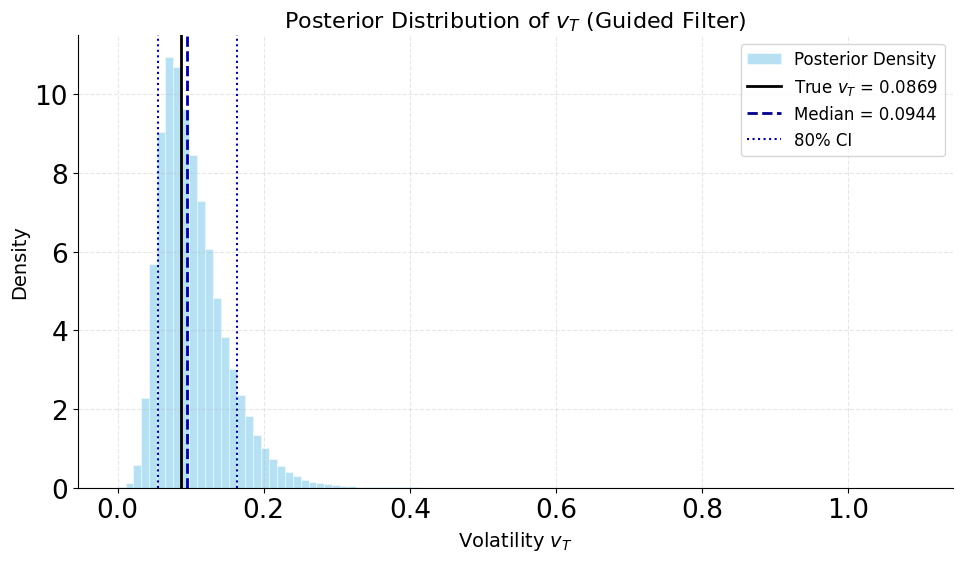

In [30]:
#| echo: false
#| output: false
M = 128
key = jax.random.PRNGKey(0)
idx = jax.random.choice(key, theta_samps.shape[0], shape=(M,), replace=False)
theta_sub = theta_samps[idx]
z_sub = z_samps[idx]
log_prob_z_sub = log_prob_z_samps[idx]
logp_prior_sub = jax.vmap(logprior_z)(z_sub)

key = jax.random.PRNGKey(0)
v_pool, logw_pool = vol_posterior_current_reweighted(key,
                                                     r_obs,
                                                     theta_sub, z_sub,
                                                     log_prob_z_sub,
                                                     heston_filter=heston_pf_filter_fast,
                                                     Npf=2048,
                                                     dt=T_total/n_steps)

q10, q50, q90 = weighted_quantile_from_logw(v_pool, logw_pool, jnp.array([0.1, 0.5, 0.9]))
print(f"Quantiles: 10%={q10:.5f}, 50%={q50:.5f}, 90%={q90:.5f}")

v_pool_mean = jnp.sum(v_pool * jnp.exp(logw_pool))
print(f"Mean: {v_pool_mean:.5f}")

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Histogram
ax.hist(v_pool, weights=jnp.exp(logw_pool), bins=100, density=True,
        alpha=0.6, color='skyblue', edgecolor='white', linewidth=0.5, label='Posterior Density')

# Vertical lines
ax.axvline(v_true[-1], color='black', linestyle='-', linewidth=2, label=f'True $v_T$ = {v_true[-1]:.4f}')
ax.axvline(q50, color='darkblue', linestyle='--', linewidth=2, label=f'Median = {q50:.4f}')
ax.axvline(q10, color='darkblue', linestyle=':', linewidth=1.5, label='80% CI')
ax.axvline(q90, color='darkblue', linestyle=':', linewidth=1.5)

# Styling
ax.set_title(r"Posterior Distribution of $v_T$ (Guided Filter)", fontsize=16)
ax.set_xlabel(r"Volatility $v_T$", fontsize=14)
ax.set_ylabel("Density", fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [31]:
#| echo: false
#| output: false

v_pool, logw_pool = vol_posterior_current_reweighted(key,
                                                     r_obs,
                                                     theta_sub, z_sub,
                                                     log_prob_z_sub,
                                                     heston_filter=heston_pf_filter_bootstrap,
                                                     Npf=2048,
                                                     dt=T_total/n_steps)

q10, q50, q90 = weighted_quantile_from_logw(v_pool, logw_pool, jnp.array([0.1, 0.5, 0.9]))
print(f"Quantiles: 10%={q10:.5f}, 50%={q50:.5f}, 90%={q90:.5f}")

v_pool_mean = jnp.sum(v_pool * jnp.exp(logw_pool))
print(f"Mean: {v_pool_mean:.5f}")

ess:  121.636086
ESS_theta: 1.0
max logw_theta: 0.0 min: -5.601242e+06
0.01 121.636086
0.03 97.70333
0.1 6.4986925
0.3 1.0040362
1.0 1.0
logZ:   mean/std/min/max -61432.586 534303.1 -5.600267e+06 977.1808
logp:   mean/std/min/max -3.2407703 1.29831 -6.905913 -1.2345935
logq:   mean/std/min/max -0.60828495 1.6337513 -6.6671257 1.8932047
raw:    mean/std/min/max -61435.227 534303.06 -5.600268e+06 974.2228
Quantiles: 10%=0.05513, 50%=0.09466, 90%=0.16426
Mean: 0.10365


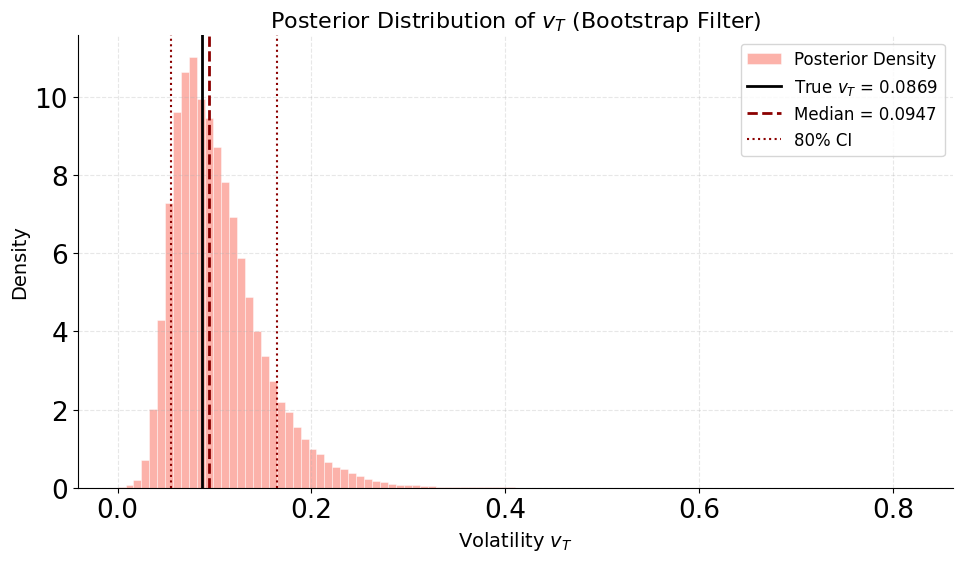

In [32]:
#| echo: false

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Histogram
ax.hist(v_pool, weights=jnp.exp(logw_pool), bins=100, density=True,
        alpha=0.6, color='salmon', edgecolor='white', linewidth=0.5, label='Posterior Density')

# Vertical lines
ax.axvline(v_true[-1], color='black', linestyle='-', linewidth=2, label=f'True $v_T$ = {v_true[-1]:.4f}')
ax.axvline(q50, color='darkred', linestyle='--', linewidth=2, label=f'Median = {q50:.4f}')
ax.axvline(q10, color='darkred', linestyle=':', linewidth=1.5, label='80% CI')
ax.axvline(q90, color='darkred', linestyle=':', linewidth=1.5)

# Styling
ax.set_title(r"Posterior Distribution of $v_T$ (Bootstrap Filter)", fontsize=16)
ax.set_xlabel(r"Volatility $v_T$", fontsize=14)
ax.set_ylabel("Density", fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


Despite this asymmetry, the posterior is well centered: the true value lies comfortably within the 80% credible interval, and the posterior median slightly overestimates $v_T$, reflecting residual uncertainty in the volatility-of-volatility parameter. The long right tail highlights the fact that high terminal volatility scenarios remain plausible given the data, a feature that would be difficult to capture with moment-based or Gaussian approximations. Overall, this marginal illustrates how the hybrid NPE + PF approach preserves uncertainty in both parameters and states without collapsing onto a single volatility trajectory.

### Smoothing
If we are interested in the complete hidden volatility trajectory $v_{0:T}$ and not just the terminal state, we have to infer the posterior distribution $p(v_{0:T} \vert S_{0:T})$ of the full history. A particle filter only uses past observations to estimate volatility at a certain time point $t$, meaning it infers $p(v_t | S_{0:t})$, which is wasteful for lower values of $t$ in the early trajectory. A common way around this problem is to apply a forward filtering backward simulation (FFBSi) algorithm (see this [survey](https://people.isy.liu.se/rt/schon/Publications/LindstenS2013.pdf) for more details) to include the information of the whole observed trajectory.

In practice, the function that implements the forward particle filter needs to get updated to store the particle trajectories, that can be fed into the backward simulator function.

The same tempered reweighting as in the filtering task can be applied to marginalize out the SDE parameters.

In [33]:
#| echo: false
#| output: false

import jax
import jax.numpy as jnp
from jax.scipy.special import logsumexp

def _normal_logpdf(x, mean, std):
    z = (x - mean) / std
    return -0.5 * (jnp.log(2.0 * jnp.pi) + 2.0 * jnp.log(std) + z * z)

def _systematic_resample(key, w):
    N = w.shape[0]
    cdf = jnp.cumsum(w)
    u0 = jax.random.uniform(key, ()) / N
    u = u0 + (jnp.arange(N, dtype=w.dtype) / N)
    idx = jnp.searchsorted(cdf, u, side="right")
    return idx.astype(jnp.int32)

def heston_pf_store_for_smoothing_bootstrap(
    key, r, theta, *, N=2048, v0=0.04, dt=1/252.0, ess_frac=0.5, v_floor=1e-8
):
    mu, kappa, theta_v, xi, rho = theta
    T = r.shape[0]
    Nf = jnp.asarray(N, jnp.float32)
    dt = jnp.asarray(dt, jnp.float32)
    sqrt_dt = jnp.sqrt(dt)

    v = jnp.ones((N,), dtype=jnp.float32) * jnp.asarray(v0, jnp.float32)
    logw = jnp.full((N,), -jnp.log(Nf), dtype=jnp.float32)  # normalized uniform

    v_hist = jnp.zeros((T + 1, N), dtype=jnp.float32).at[0].set(v)
    logw_hist = jnp.zeros((T, N), dtype=jnp.float32)

    def step(carry, t):
        v, logw = carry
        rt = r[t]

        # weight using v_t
        v_pos = jnp.maximum(v, v_floor)
        obs_mean = (mu - 0.5 * v_pos) * dt
        obs_std  = jnp.sqrt(v_pos) * sqrt_dt + 1e-8
        ll = _normal_logpdf(rt, obs_mean, obs_std)

        lse = logsumexp(logw + ll)
        logw = logw + ll - lse
        logw_hist_t = logw
        w = jnp.exp(logw)

        ess = 1.0 / jnp.sum(w * w)
        do_resample = ess < (ess_frac * Nf)

        key_r = jax.random.fold_in(key, t * 2 + 0)
        idx = jax.lax.cond(
            do_resample,
            lambda _: _systematic_resample(key_r, w),
            lambda _: jnp.arange(N, dtype=jnp.int32),
            operand=None,
        )
        v = v[idx]
        logw = jax.lax.cond(
            do_resample,
            lambda _: jnp.full_like(logw, -jnp.log(Nf)),
            lambda _: logw,
            operand=None,
        )

        # propagate v_{t+1} ~ p(v_{t+1} | v_t) (Euler)
        key_e = jax.random.fold_in(key, t * 2 + 1)
        eps = jax.random.normal(key_e, (N,), dtype=jnp.float32)

        v_pos = jnp.maximum(v, v_floor)
        v_next = v + kappa * (theta_v - v) * dt + xi * (jnp.sqrt(v_pos) * sqrt_dt) * eps
        v_next = jnp.maximum(v_next, v_floor)

        return (v_next, logw), (v_next, logw_hist_t)

    (vT, logwT), (v_seq, logw_seq) = jax.lax.scan(step, (v, logw), jnp.arange(T))
    v_hist = v_hist.at[1:].set(v_seq)
    logw_hist = logw_hist.at[:].set(logw_seq)
    return v_hist, logw_hist


def heston_pf_store_for_smoothing_guided(
    key, r, theta, *, N=2048, v0=0.04, dt=1/252.0, ess_frac=0.5, v_floor=1e-8
):
    """
    Guided PF store for FFBSi smoothing.

    Returns:
      v_hist:    [T+1, N] particles v_t  (t=0..T)
      logw_hist: [T,   N] normalized log weights for v_t given r_{1:t} (stored BEFORE resampling)
                 i.e. logsumexp(logw_hist[t]) == 0

    Notes:
      - Weighting uses p(r_t | v_t) (as in your bootstrap store).
      - Propagation uses a guided proposal based on rho and the observed return r_t.
      - Good for conditional state inference; not recommended as a theta-likelihood estimator.
    """
    mu, kappa, theta_v, xi, rho = theta
    T = r.shape[0]
    Nf = jnp.asarray(N, jnp.float32)
    dt = jnp.asarray(dt, jnp.float32)
    sqrt_dt = jnp.sqrt(dt)

    v = jnp.ones((N,), dtype=jnp.float32) * jnp.asarray(v0, jnp.float32)
    logw = jnp.full((N,), -jnp.log(Nf), dtype=jnp.float32)  # normalized uniform

    v_hist = jnp.zeros((T + 1, N), dtype=jnp.float32).at[0].set(v)
    logw_hist = jnp.zeros((T, N), dtype=jnp.float32)

    sqrt_one_m_rho2 = jnp.sqrt(jnp.maximum(1.0 - rho * rho, 0.0))

    def step(carry, t):
        v, logw = carry
        rt = r[t]

        # ---- weight using v_t: p(r_t | v_t)
        v_pos = jnp.maximum(v, v_floor)
        obs_mean = (mu - 0.5 * v_pos) * dt
        obs_std  = jnp.sqrt(v_pos) * sqrt_dt + 1e-8
        ll = _normal_logpdf(rt, obs_mean, obs_std)

        # normalize log weights and store for smoothing
        lse = logsumexp(logw + ll)
        logw = logw + ll - lse                       # normalized
        logw_hist_t = logw                            # store BEFORE resampling
        w = jnp.exp(logw)

        ess = 1.0 / jnp.sum(w * w)
        do_resample = ess < (ess_frac * Nf)

        key_r = jax.random.fold_in(key, t * 2 + 0)
        idx = jax.lax.cond(
            do_resample,
            lambda _: _systematic_resample(key_r, w),
            lambda _: jnp.arange(N, dtype=jnp.int32),
            operand=None,
        )
        v = v[idx]
        logw = jax.lax.cond(
            do_resample,
            lambda _: jnp.full_like(logw, -jnp.log(Nf)),
            lambda _: logw,
            operand=None,
        )

        # ---- guided propagation using r_t and rho
        v_pos = jnp.maximum(v, v_floor)

        # "standardized return shock" given v_t
        y = (rt - (mu - 0.5 * v_pos) * dt) / (jnp.sqrt(v_pos) * sqrt_dt + 1e-8)

        key_e = jax.random.fold_in(key, t * 2 + 1)
        eps = jax.random.normal(key_e, (N,), dtype=jnp.float32)

        eps_v = rho * y + sqrt_one_m_rho2 * eps

        v_next = v + kappa * (theta_v - v) * dt + xi * (jnp.sqrt(v_pos) * sqrt_dt) * eps_v
        v_next = jnp.maximum(v_next, v_floor)

        return (v_next, logw), (v_next, logw_hist_t)

    (vT, logwT), (v_seq, logw_seq) = jax.lax.scan(step, (v, logw), jnp.arange(T))
    v_hist = v_hist.at[1:].set(v_seq)
    logw_hist = logw_hist.at[:].set(logw_seq)
    return v_hist, logw_hist



In [34]:
#| echo: false
#| output: false
import jax
import jax.numpy as jnp
from jax.scipy.special import logsumexp

def _normal_logpdf(x, mean, std):
    z = (x - mean) / std
    return -0.5 * (jnp.log(2.0 * jnp.pi) + 2.0 * jnp.log(std) + z * z)

def log_transition_v_euler(v_next, v_curr, theta, dt, v_floor=1e-8):
    """
    Euler transition density used by the *bootstrap* PF propagation:
      v_{t+1} = v_t + kappa(theta_v - v_t) dt + xi sqrt(v_t^+) sqrt(dt) eps, eps~N(0,1)
    """
    _, kappa, theta_v, xi, _ = theta
    v_pos = jnp.maximum(v_curr, v_floor)
    mean = v_curr + kappa * (theta_v - v_curr) * dt
    std  = xi * jnp.sqrt(v_pos * dt) + 1e-8
    return _normal_logpdf(v_next, mean, std)  # broadcasts over v_curr [N]

def ffbsim_v_paths(
    key,
    v_hist,        # [T+1, N]
    logw_hist,     # [T,   N] normalized log weights for filtering dist at time t (on v_t)
    theta,
    *,
    dt,
    n_paths=256,
    v_floor=1e-8,
):
    """
    FFBSi backward simulation smoother for the bootstrap PF.

    Inputs:
      v_hist[t]      = particles representing v_t  (after propagation to time t)
      logw_hist[t]   = log p(v_t^i | r_{1:t+1}) up to normalization (stored after weighting at time t),
                       i.e. weights associated with v_t at time t.

    Returns:
      v_paths: [n_paths, T+1] sampled trajectories v_{0:T}
    """
    T = logw_hist.shape[0]
    N = v_hist.shape[1]

    # Terminal selection: sample index at time T using filtering weights at time T-1 on v_T
    # Note: in our store, v_hist has length T+1 with v_hist[T] being v_T.
    #       logw_hist[T-1] corresponds to weights after assimilating r_{T-1}.
    key, sub = jax.random.split(key)
    idx_T = jax.random.categorical(sub, logw_hist[T - 1], shape=(n_paths,))  # [n_paths]

    def one_path(k, idxT):
        # store chosen ancestor indices
        idxs = jnp.zeros((T + 1,), dtype=jnp.int32).at[T].set(idxT)

        def back_step(carry, t_rev):
            k, idxs = carry
            t = T - 1 - t_rev  # goes T-1, ..., 0

            v_next = v_hist[t + 1, idxs[t + 1]]            # scalar
            log_trans = log_transition_v_euler(
                v_next, v_hist[t], theta, dt, v_floor=v_floor
            )                                               # [N]
            logb = logw_hist[t] + log_trans                 # [N]

            k, subk = jax.random.split(k)
            idx_t = jax.random.categorical(subk, logb)      # scalar index in [0, N)
            idxs = idxs.at[t].set(idx_t)
            return (k, idxs), None

        (k, idxs), _ = jax.lax.scan(back_step, (k, idxs), jnp.arange(T))
        return v_hist[jnp.arange(T + 1), idxs]              # [T+1]

    keys = jax.random.split(key, n_paths)
    v_paths = jax.vmap(one_path)(keys, idx_T)
    return v_paths


In [35]:
#| echo: false
#| output: false
key = jax.random.PRNGKey(0)
theta_hat = jnp.mean(theta_samps, axis=0
                     )
# r_obs: [T] returns
# theta_hat: (mu, kappa, theta_v, xi, rho)  (rho is unused by bootstrap PF, but keep it in the tuple)

v_hist, logw_hist = heston_pf_store_for_smoothing_guided(
    key,
    r_obs,
    theta_hat,
    N=2048,
    v0=0.04,
    dt=1.0/252.0,
    ess_frac=0.5,
)
# v_hist:    [T+1, N]
# logw_hist: [T,   N]


In [36]:
#| echo: false
#| output: false
key = jax.random.PRNGKey(1)

v_paths = ffbsim_v_paths(
    key,
    v_hist,
    logw_hist,
    theta_hat,
    dt=1.0/252.0,
    n_paths=256,
)
# v_paths: [n_paths, T+1]

q10 = jnp.quantile(v_paths, 0.10, axis=0)
q50 = jnp.quantile(v_paths, 0.50, axis=0)
q90 = jnp.quantile(v_paths, 0.90, axis=0)


vT_paths = v_paths[:, -1]
print(jnp.quantile(vT_paths, jnp.array([0.1, 0.5, 0.9])))


[0.07358786 0.10440107 0.15390445]


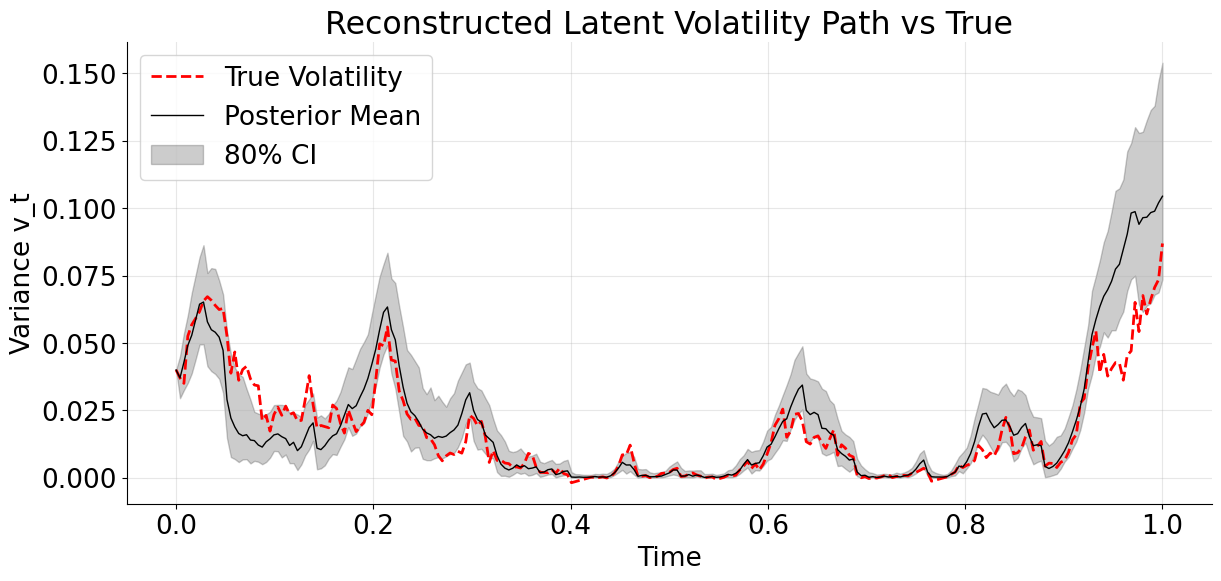

In [37]:
#| echo: false
#| output: false
plt.figure(figsize=(14, 6))
plt.plot(ts, v_true, 'r--', label='True Volatility', lw=2)
plt.plot(ts, q50, 'k-', label='Posterior Mean', lw=1)
plt.fill_between(ts, q10, q90, color='k', alpha=0.2, label='80% CI')
plt.title('Reconstructed Latent Volatility Path vs True')
plt.xlabel('Time')
plt.ylabel('Variance v_t')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [38]:
#| echo: false
#| output: falseM = 64
theta_sub = theta_samps[:M]

def one_theta(key, th):
    v_hist, logw_hist = heston_pf_store_for_smoothing_guided(
        key, r_obs, th, N=1024, v0=0.04, dt=T_total/n_steps, ess_frac=0.5
    )
    key2 = jax.random.fold_in(key, 999)
    v_paths = ffbsim_v_paths(key2, v_hist, logw_hist, th, dt=T_total/n_steps, n_paths=64)
    return v_paths  # [N, T+1]

keys = jax.random.split(jax.random.PRNGKey(0), M)
all_paths = jax.vmap(one_theta)(keys, theta_sub)          # [M, N, T+1]
all_paths = all_paths.reshape(-1, all_paths.shape[-1])    # [M*N, T+1]


In [39]:
#| echo: false
#| output: false
q10_all = jnp.quantile(all_paths, 0.10, axis=0)
q50_all = jnp.quantile(all_paths, 0.50, axis=0)
q90_all = jnp.quantile(all_paths, 0.90, axis=0)

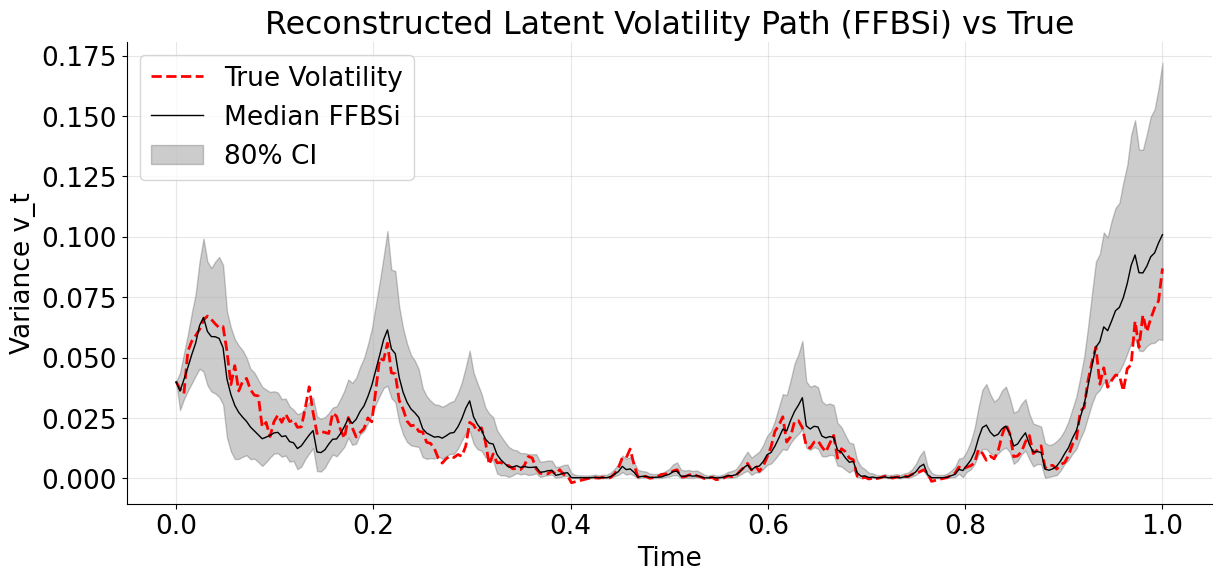

In [40]:
#| echo: false
plt.figure(figsize=(14, 6))
plt.plot(ts, v_true, 'r--', label='True Volatility', lw=2)
plt.plot(ts, q50_all, 'k-', label='Median FFBSi', lw=1)
plt.fill_between(ts, q10_all, q90_all, color='k', alpha=0.2, label='80% CI')
plt.title('Reconstructed Latent Volatility Path (FFBSi) vs True')
plt.xlabel('Time')
plt.ylabel('Variance v_t')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The median FFBSi trajectory follows the level, timing, and regime changes of the true latent variance meaningfully. The 80% credible interval behaves sensibly, widening when volatility is high and tightening in calm regimes. The true path stays inside the band most of the time, without the band being trivially over-wide. The variance increases sharply toward the end, but this is a realistic behavior at the end-of-horizon where information progressively disappears.

The two-stages method clearly shines here by guiding the FFBSi smoothing with better parameter estimates from the NPE stage than what is achieved with MCLMC.

## Conclusion

We considered two different ways of performing Bayesian inference in the Heston stochastic volatility model, and how those choices affect both parameter estimates and inferred volatility paths. Gradient-based methods like MCLMC can work remarkably well in practice: they recover the timing of volatility regimes and produce clean-looking posteriors. However, when the latent dynamics is discretized and treated as exact, these methods tend to absorb model error into weakly identifiable parameters, leading to overly confident and systematically biased inference, especially for diffusion-related quantities.

To get around this, we explored a hybrid strategy that separates the problem into two pieces. Neural posterior estimation is used to infer SDE parameters from informative summary statistics of the observed trajectory, without ever differentiating through latent volatility paths. Particle filtering and smoothing are then applied conditionally on sampled parameters to recover latent volatility trajectories and marginal state uncertainty. This decoupling turns out to be crucial: uncertainty that would otherwise collapse into biased point estimates is instead preserved and propagated downstream.

In practice, the NPE + PF approach produces broader but better-calibrated parameter posteriors and more realistic volatility reconstructions. Sharp volatility spikes are no longer systematically damped, credible intervals behave sensibly, and marginal state distributions remain skewed where they should be. While the method is more computationally involved than a single end-to-end sampler, it provides a clearer picture of what the data actually support, and what they do not.

More generally, this case study highlights a common pitfall in latent SDE inference: when models are approximate, apparent precision can be misleading. In such settings, inference pipelines that modularize uncertainty and avoid over-committing to discretized dynamics can offer a more robust and interpretable alternative.